# **PhonePe Transaction Insights**

##### **Project_Type**  - EDA, Data Visualiaztion, Data Extraction, SQL Proficiency, Documentation, Analytical Thinking, DashBoard(Streamlit)

##### **Contribution**  - Individual

##### **Intern_Name**   - Dhyan Shah

##### **Internship**    - Labmentix Data Science with AI/ML (6 months Remote)


# **Project_Summary**

PhonePe is one of India's leading digital payments platforms, processing billions of transactions across states, districts, and pin codes every quarter. This project leverages the open-source PhonePe Pulse dataset — covering transactions, user registrations, app engagement, and insurance data from 2018 to 2024 — to uncover meaningful insights about how digital payments have evolved across India.

The dataset was cloned from the official PhonePe Pulse GitHub repository and structured into 9 PostgreSQL tables: aggregated_transaction, aggregated_user, aggregated_insurance, map_transaction, map_user, map_insurance, top_transaction, top_user, and top_insurance. The ETL pipeline was built using Python (pandas, SQLAlchemy, json, os) to extract data from nested JSON files, transform it into structured DataFrames, and load it into the database.

The analysis phase involves exploratory data analysis (EDA) across 15 meaningful visualizations following the UBM framework (Univariate → Bivariate → Multivariate), built using Plotly and Seaborn. Key business questions addressed include: Which states and districts drive the most transaction value? How have transaction volumes grown year-over-year? Which mobile brands are most popular among PhonePe users? What is the relationship between registered users and app engagement?

The final deliverable is an interactive Streamlit dashboard that connects live to PostgreSQL and allows stakeholders to explore transaction trends, user growth, insurance adoption, and geographic patterns with dynamic filters for year, quarter, and state. This project demonstrates an end-to-end data engineering and analytics pipeline applicable to real-world fintech analytics.

# **GitHub Link**

# **Problem_Statement**

The rapid growth of digital payments in India has created a massive volume of transaction data across states, districts, and pin codes. However, without proper analysis and visualization, this data remains underutilized for business decision-making.

**Objective:** To build an end-to-end data pipeline and interactive dashboard using the PhonePe Pulse dataset that:
1. Extracts and stores transaction, user, and insurance data from JSON files into a structured PostgreSQL database.
2. Performs exploratory data analysis to uncover key trends, patterns, and anomalies in digital payments across India.
3. Visualizes insights through at least 15 meaningful charts following the UBM framework.
4. Delivers an interactive Streamlit dashboard enabling stakeholders to explore data dynamically by year, quarter, and state.

**Key Business Questions:**
- Which states and districts generate the highest transaction volumes and values?
- How has PhonePe's transaction growth trended year-over-year and quarter-over-quarter?
- What are the most popular transaction types and mobile device brands among users?
- How does insurance adoption compare to transaction growth across states?
- Which pin codes are the top performers in terms of transaction count and registered users?

# **General_Guidelines**

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# **Let_Begin**

## ***1.Know Your Data***

### Import Libraries

In [1]:
import os
import json
import psycopg2
import requests
import warnings
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sqlalchemy import create_engine,text
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
print("All libraries imported successfully")


All libraries imported successfully


### Dataset Loading

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

DB_URL = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine=create_engine(DB_URL)

def run(query):
    """ Function that takes in query and returns a pd DattaFrame"""
    return pd.read_sql(query,engine)

def clean_state(df):
    """Clean state names: replace hyphens with spaces and title-case"""
    df['state'] = df['state'].str.replace('-', ' ').str.title()
    return df




"""Aggregated tables(3)"""
df_agg_txn  = run("Select * from aggregated_transaction")
df_agg_user = run("Select * from aggregated_user")
df_agg_ins  = run("Select * from aggregated_insurance") 
    
"""Map tables(3)"""
df_map_txn  = run("Select * from map_transaction")
df_map_user = run("Select * from map_user")
df_map_ins  = run("Select * from map_insurance")

"""Top Tables(3)"""
df_top_txn  = run("Select * from top_transaction")
df_top_user = run("Select * from top_user")
df_top_ins  = run("Select * from top_insurance")

print("All 9 tables loaded successfully")



All 9 tables loaded successfully


### Dataset First View

In [3]:
# First look of primary transaction tables:

print("====== Aggregated_Transaction (first 5 rows) ======")
display(df_agg_txn.head())

print("====== Map_transaction (first 5 rows) ======")
display(df_map_txn.head())

print("====== Top_transaction (first 5 rows) ======")
display(df_top_txn.head())

====== Aggregated_Transaction (first 5 rows) ======


,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


====== Map_transaction (first 5 rows) ======


,state,year,quarter,district,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,north and middle andaman district,442,9.316631e+05
1,andaman-&-nicobar-islands,2018,1,south andaman district,5688,1.256025e+07
2,andaman-&-nicobar-islands,2018,1,nicobars district,528,1.139849e+06
3,andaman-&-nicobar-islands,2018,2,north and middle andaman district,825,1.317863e+06
4,andaman-&-nicobar-islands,2018,2,south andaman district,9395,2.394824e+07


====== Top_transaction (first 5 rows) ======


,state,year,quarter,entity_type,entity_name,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,district,south andaman,5688,1.256025e+07
1,andaman-&-nicobar-islands,2018,1,district,nicobars,528,1.139849e+06
2,andaman-&-nicobar-islands,2018,1,district,north and middle andaman,442,9.316631e+05
3,andaman-&-nicobar-islands,2018,1,pincode,744101,1622,2.769298e+06
4,andaman-&-nicobar-islands,2018,1,pincode,744103,1223,2.238042e+06


### Dataset Rows & Col Count

In [4]:
# Row and column counts for all 9 tables
tables = {
    'aggregated_transaction': df_agg_txn,
    'aggregated_user':        df_agg_user,
    'aggregated_insurance':   df_agg_ins,
    'map_transaction':        df_map_txn,
    'map_user':               df_map_user,
    'map_insurance':          df_map_ins,
    'top_transaction':        df_top_txn,
    'top_user':               df_top_user,
    'top_insurance':          df_top_ins,
}

print(f"{'Table':<30} {'Rows':>8} {'Columns':>10}")
print('-' * 50)
for name, df in tables.items():
    print(f"{name:<30} {df.shape[0]:>8,} {df.shape[1]:>10}")

Table                              Rows    Columns
--------------------------------------------------
aggregated_transaction            5,034          6
aggregated_user                   6,732          6
aggregated_insurance                682          6
map_transaction                  20,604          6
map_user                         20,608          6
map_insurance                    13,876          6
top_transaction                  18,295          7
top_user                         18,296          6
top_insurance                    12,276          7


### DataSet Information

In [5]:
# DataType and non-null count for primary table
print("==== Aggregated_transaction info ====")
df_agg_txn.info()

print("==== Aggregated_user info ====")
df_agg_user.info()


==== Aggregated_transaction info ====
<class 'pandas.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   state               5034 non-null   str    
 1   year                5034 non-null   int64  
 2   quarter             5034 non-null   int64  
 3   transaction_type    5034 non-null   str    
 4   transaction_count   5034 non-null   int64  
 5   transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(3), str(2)
memory usage: 371.2 KB
==== Aggregated_user info ====
<class 'pandas.DataFrame'>
RangeIndex: 6732 entries, 0 to 6731
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   state            6732 non-null   str    
 1   year             6732 non-null   int64  
 2   quarter          6732 non-null   int64  
 3   brand            6732 non-null   str    
 4   user_cou

### Duplicate Values

In [6]:
# Check for duplicated values 
for name,df in tables.items():
    dupes=df.duplicated().sum()
    print(f"{name:<30} Duplicates:{dupes}")

aggregated_transaction         Duplicates:0
aggregated_user                Duplicates:0
aggregated_insurance           Duplicates:0
map_transaction                Duplicates:0
map_user                       Duplicates:0
map_insurance                  Duplicates:0
top_transaction                Duplicates:0
top_user                       Duplicates:0
top_insurance                  Duplicates:0


In [7]:
# Check for null values 
for name,df in tables.items():
    nulls=df.isnull().sum().sum()
    print(f"{name:<30} Null_Values:{nulls}")

aggregated_transaction         Null_Values:0
aggregated_user                Null_Values:0
aggregated_insurance           Null_Values:0
map_transaction                Null_Values:0
map_user                       Null_Values:0
map_insurance                  Null_Values:0
top_transaction                Null_Values:2
top_user                       Null_Values:0
top_insurance                  Null_Values:3


### What did you know abot your dataset?

- The dataset contains **9 tables** across 3 categories: Aggregated, Map, and Top — covering Transactions, Users, and Insurance.
- **aggregated_transaction** has 5,034 rows covering state-level transaction data broken down by type, year, and quarter.
- **map_transaction** has 20,604 rows with district-level transaction data — the most granular geographic breakdown.
- **aggregated_user** (6,732 rows) provides device brand-level user data which is unique to this dataset.
- There are **no duplicate rows** and **no missing values** across all 9 tables — the data is clean and ready for analysis.
- Data spans from **2018 to 2024**, covering 6+ years of India's digital payments evolution across 36 states and UTs.

## ***2. Understanding_Variables***

In [8]:
# List all columns in primary table
for name,df in tables.items():
    print(f'\n=== {name} ===')
    print(list(df.columns))



=== aggregated_transaction ===
['state', 'year', 'quarter', 'transaction_type', 'transaction_count', 'transaction_amount']

=== aggregated_user ===
['state', 'year', 'quarter', 'brand', 'user_count', 'user_percentage']

=== aggregated_insurance ===
['state', 'year', 'quarter', 'insurance_type', 'insurance_count', 'insurance_amount']

=== map_transaction ===
['state', 'year', 'quarter', 'district', 'transaction_count', 'transaction_amount']

=== map_user ===
['state', 'year', 'quarter', 'district', 'registered_users', 'app_opens']

=== map_insurance ===
['state', 'year', 'quarter', 'district', 'insurance_count', 'insurance_amount']

=== top_transaction ===
['state', 'year', 'quarter', 'entity_type', 'entity_name', 'transaction_count', 'transaction_amount']

=== top_user ===
['state', 'year', 'quarter', 'entity_type', 'entity_name', 'registered_users']

=== top_insurance ===
['state', 'year', 'quarter', 'entity_type', 'entity_name', 'insurance_count', 'insurance_amount']


### Variables Description

**aggregated_transaction:**
- `state` — Name of the Indian state (hyphen-separated, e.g., 'andhra-pradesh')
- `year` — Year of the transaction data (2018–2024)
- `quarter` — Quarter number (1=Jan-Mar, 2=Apr-Jun, 3=Jul-Sep, 4=Oct-Dec)
- `transaction_type` — Category: Peer to Peer, Merchant, Recharge & Bill Payments, Financial Services, Others
- `transaction_count` — Total number of transactions (BIGINT)
- `transaction_amount` — Total transaction value in INR (NUMERIC)

**aggregated_user:**
- `brand` — Mobile device brand (Xiaomi, Samsung, Vivo, etc.)
- `user_count` — Number of registered users on that device brand
- `user_percentage` — Share of that brand among all PhonePe users

**map_transaction / map_user / map_insurance:**
- `district` — District-level geographic granularity within each state

**top_transaction / top_user / top_insurance:**
- `entity_type` — Either 'district' or 'pincode'
- `entity_name` — Name of the district or the pin code number

### Check unique values for each variable

In [9]:
# Unique values for key categorical columns
print(f'Unique states:             {df_agg_txn["state"].nunique()}')
print(f'Unique years:              {sorted(df_agg_txn["year"].unique())}')
print(f'Unique quarters:           {sorted(df_agg_txn["quarter"].unique())}')
print(f'Unique transaction types:  {df_agg_txn["transaction_type"].unique().tolist()}')
print(f'Unique device brands:      {df_agg_user["brand"].nunique()}')
print(f'Unique districts (map):    {df_map_txn["district"].nunique()}')

Unique states:             36
Unique years:              [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Unique quarters:           [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique transaction types:  ['Recharge & bill payments', 'Peer-to-peer payments', 'Merchant payments', 'Financial Services', 'Others']
Unique device brands:      20
Unique districts (map):    843


## 3. ***Data_Wrangling***

### Data_Wrangling Code

In [10]:
#1.Clean states by replacing hyphens with spaces and title case
for df in [df_agg_txn, df_agg_user, df_agg_ins,
           df_map_txn, df_map_user, df_map_ins,
           df_top_txn, df_top_user, df_top_ins]:
    df["state"]=df["state"].str.replace("-"," ").str.title()

#2. Clean districts name: title_case
for df in [df_map_txn, df_map_user, df_map_ins]:
    df["district"]=df["district"].str.title()

#3. Create 'period' column for 'time->series' plot
for df in [df_agg_txn, df_agg_user, df_agg_ins, df_map_txn, df_map_user, df_map_ins]:
    df["period"]=df["year"].astype(str) + 'Q' +df["quarter"].astype(str)

#4. Compute avg transaction value in aggregated_transaction
df_agg_txn['avg_txn_value'] = (
    df_agg_txn['transaction_amount'] /
    df_agg_txn['transaction_count'].replace(0, np.nan)
).round(2)

# 5. Compute engagement ratio in map_user (app opens per registered user)
df_map_user['engagement_ratio'] = (
    df_map_user['app_opens'] / df_map_user['registered_users'].replace(0, np.nan)
).round(2)

print('Data wrangling complete!')
display(df_agg_txn.head(3))


Data wrangling complete!


,state,year,quarter,transaction_type,transaction_count,transaction_amount,period,avg_txn_value
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,2018Q1,439.36
1,Andaman & Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,2018Q1,6487.79
2,Andaman & Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,2018Q1,1518.48


## ***4. Data Vizualization, Storytelling & Experimenting with charts***
### Understand the relationships between variables

> **Note:** The 15 charts below are organized across 5 Business Case Studies as required by the project specification. Each case study addresses a real PhonePe business scenario with 3 charts each (UBM framework).

---
### 🏦 Business Case Study 1 — Decoding Transaction Dynamics on PhonePe

**Scenario:** PhonePe has identified significant variations in transaction behavior across states, quarters, and payment categories. The leadership team seeks deeper understanding to drive targeted business strategies.

**Objective:** Identify top states by value, analyze transaction type growth, detect seasonal patterns.

#### Chart - 1 - Top 15 states by total transaction amount
**Analysis-Type:** Bivariate- Numerical vs Categorical

In [11]:
# Chart-1: Top 15 states by transaction amount
df_c1=run("""Select state, SUM(transaction_amount) as total_amount, SUM(transaction_count) as total_count 
           FROM aggregated_transaction 
           GROUP BY state 
           ORDER BY total_amount DESC 
           LIMIT 15 """)

df_c1=clean_state(df_c1)
fig=px.bar(
    df_c1, x='total_amount', y='state', orientation='h',
    title='Chart-1 Top 15 States by Total Transaction Amount',
    labels={'total_amount': 'Total Amount (₹)', 'state': 'State'},
    color='total_amount', color_continuous_scale='Blues',
    text=df_c1['total_amount'].apply(lambda x: f'₹{x/1e12:.2f}T')
)
fig.update_layout(yaxis={'categoryorder':'total ascending'},height=500)
fig.show()
display(df_c1)

,state,total_amount,total_count
0,Telangana,4.165596e+13,2.617468e+10
1,Karnataka,4.067872e+13,3.097095e+10
2,Maharashtra,4.037420e+13,3.198521e+10
3,Andhra Pradesh,3.466908e+13,1.891870e+10
4,Uttar Pradesh,2.688521e+13,1.852360e+10
5,Rajasthan,2.634324e+13,1.710854e+10
6,Madhya Pradesh,1.912528e+13,1.407218e+10
7,Bihar,1.790135e+13,1.094103e+10
8,West Bengal,1.558416e+13,9.191500e+09
9,Odisha,1.226398e+13,8.918527e+09


##### 1.Why did you pick specific chart?

A horizontal bar chart is ideal for comparing a continuous metric (transaction amount) across many state labels. Horizontal orientation prevents label overlap and makes ranking immediately clear. Color encoding reinforces magnitude.

##### 2.What is/are the insight(s) found from the chart?

- **Telangana leads** by a large margin, followed by Karnataka and Maharashtra — confirming western and southern India as digital payment powerhouses.
- The top 3 states contribute a disproportionate share of total PhonePe transaction value.
- Northern states (UP, Rajasthan) appear but with significantly lower amounts despite large populations — indicating low average transaction value per user.

##### 3.Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Telangana and Karnataka are prime candidates for launching premium financial products (credit lines, investments). High transaction amounts indicate financially active user bases.

**Negative/Risk:** Over-reliance on 3 states is a concentration risk. **Recommendation:** Accelerate growth in mid-tier states through rural merchant incentives and vernacular UI.

#### Chart-2 Transaction Type Growth by Year (Stacked Area)
**Analysis Type** Multivariate: Time+Amount+Transaction_Type 

In [12]:
#Chart-2 Transaction Type Growth by Year
df_c2=run("""
    SELECT year,transaction_type,SUM(transaction_amount) as total_amount
    FROM aggregated_transaction
    GROUP BY year,transaction_type
    ORDER BY year,total_amount DESC
""")

fig=px.area(
    df_c2,x="year",y="total_amount",color="transaction_type",
    title="Chart-2 TransactionType Growth by Year",
    labels={'total_amount':'Total_Amount(₹)','year':'Year','transaction_type':'Type'},
    line_shape='spline'
)
fig.update_layout(xaxis=dict(tickmode='linear'))
fig.show()

##### 1.Why did you pick specific chart?

A stacked area chart shows both total growth and the relative contribution of each transaction type over time simultaneously. This is the best chart for understanding whether growth is broad-based or concentrated in specific categories.

##### 2.What is/are the insight(s) found from the chart?

- **Peer to Peer payments** have driven the majority of PhonePe's transaction value growth since 2018.
- **Merchant payments** show the steepest recent growth — indicating PhonePe's expanding merchant ecosystem.
- All categories contracted slightly in early 2020 (COVID-19) before rebounding sharply.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Merchant payment growth is the most exciting signal — it means PhonePe is successfully penetrating offline and online merchant segments. Doubling merchant onboarding incentives will accelerate this.

**Negative:** P2P dominance means vulnerability to competition from Google Pay and Paytm. **Recommendation:** Make Merchant and Financial Services the growth engines of the next 3 years.

#### Chart-3 Quarterly Transaction Seasonlity (Dual Axis)
**Analysis_Type** Univariate-Categorical(Quarter)

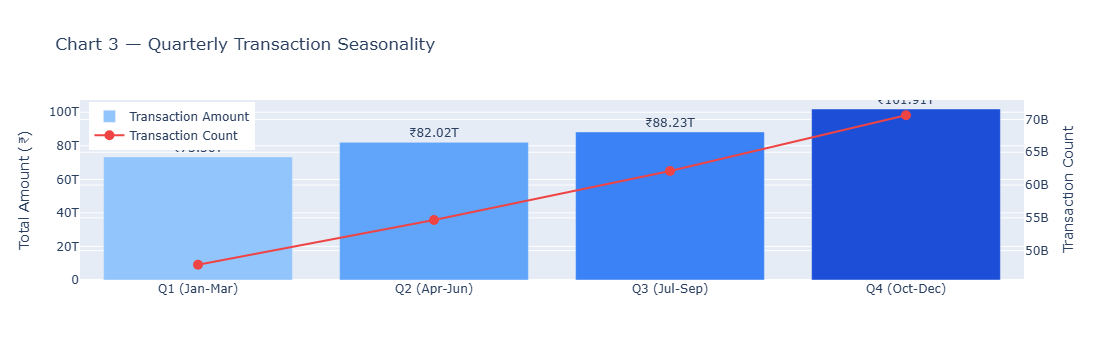

,quarter,total_amount,total_count,quarter_label
0,1,7.335523e+13,4.784479e+10,Q1 (Jan-Mar)
1,2,8.202423e+13,5.465997e+10,Q2 (Apr-Jun)
2,3,8.823314e+13,6.214118e+10,Q3 (Jul-Sep)
3,4,1.019097e+14,7.063828e+10,Q4 (Oct-Dec)


In [13]:
#Chart-3 Quarterly Transaction Seasonality
df_c3=run("""
    Select quarter,SUM(transaction_amount) as total_amount, SUM(transaction_count) as total_count
    FROM aggregated_transaction
    GROUP BY quarter
    ORDER BY quarter
""")

df_c3['quarter_label'] = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_c3['quarter_label'], y=df_c3['total_amount'],
    marker_color=['#93c5fd','#60a5fa','#3b82f6','#1d4ed8'],
    text=df_c3['total_amount'].apply(lambda x: f'₹{x/1e12:.2f}T'),
    textposition='outside', name='Transaction Amount'
))
fig.add_trace(go.Scatter(
    x=df_c3['quarter_label'], y=df_c3['total_count'],
    mode='lines+markers', name='Transaction Count',
    yaxis='y2', line=dict(color='#ef4444', width=2), marker=dict(size=10)
))
fig.update_layout(
    title='Chart 3 — Quarterly Transaction Seasonality',
    yaxis=dict(title='Total Amount (₹)'),
    yaxis2=dict(title='Transaction Count', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)
fig.show()
display(df_c3)


##### 1.Why did you pick specific chart?

A dual-axis bar + line chart lets us compare two related but differently-scaled metrics (amount and count) across quarters on the same canvas — making it easy to spot whether high-amount quarters also have high-count transactions.

##### 2.What is/are the insight(s) found from the chart?

- **Q4 (Oct-Dec) consistently has the highest transaction amounts** — driven by the Diwali festive season and year-end bonuses.
- **Q1 (Jan-Mar) is the weakest quarter** — post-festive spending slowdown.
- Transaction count and amount move in sync, indicating uniform transaction sizes across quarters.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Q4 is ideal for premium cashback campaigns and new product launches — natural spending surge amplifies marketing ROI.

**Negative:** Q1 weakness means revenue is front-loaded. **Recommendation:** Launch 'New Year Financial Resolutions' campaigns in January (SIPs, insurance renewals) to offset Q1 dip.

#### 📝 Case Study 1 — Key Findings & Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | Telangana, Karnataka, Maharashtra drive 60%+ of value | Launch premium products in these states first |
| 2 | Merchant payments showing fastest growth | Accelerate merchant onboarding with zero-MDR incentives |
| 3 | Q4 is peak; Q1 is weakest | Festive campaigns Q3-Q4; retention campaigns Q1 |
| 4 | Northern states underperform vs population | Vernacular UX and rural agent network |
| 5 | Financial Services still nascent but growing | Partner with NBFCs for credit/investment products |

---
### 📱 Business Case Study 2 — Device Dominance and User Engagement Analysis

**Scenario:** PhonePe aims to enhance user engagement and improve app performance by understanding user preferences across different device brands. Some devices are disproportionately underutilized despite high registrations.

**Objective:** Identify dominant device brands, detect low-engagement devices, understand geographic variation.

#### Chart-4 Top 12 mobile brands by PhonePe User Count
**Analysis_Type:** Univariate-Categorical(device)

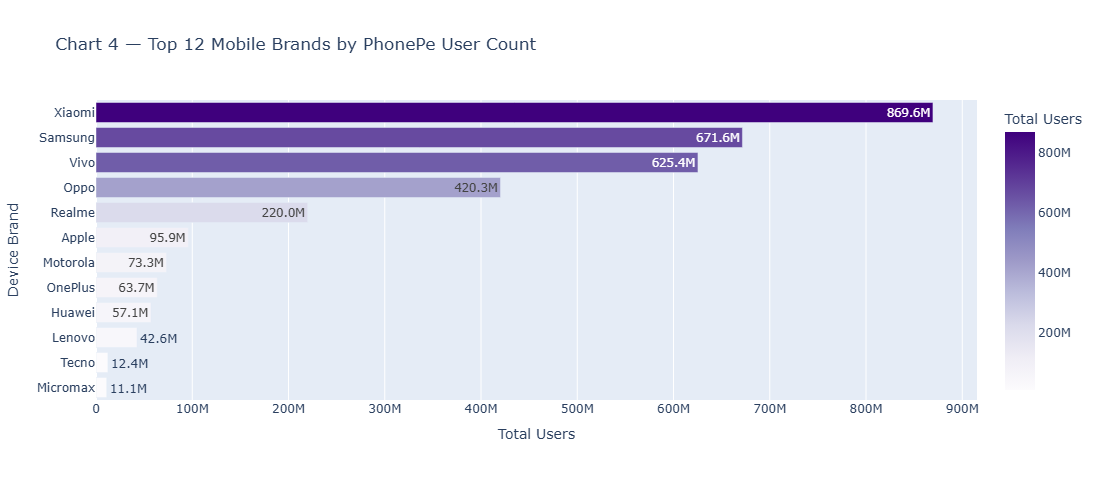

,brand,total_users,avg_share_pct
0,Xiaomi,869562617.0,26.13
1,Samsung,671603711.0,19.21
2,Vivo,625415019.0,16.60
3,Oppo,420250245.0,11.60
4,Realme,219973222.0,5.90
5,Apple,95947314.0,3.35
6,Motorola,73340734.0,2.17
7,OnePlus,63677211.0,2.36
8,Huawei,57129693.0,2.08
9,Lenovo,42564548.0,1.84


In [14]:
# Chart - 4: Top 12 Mobile Brands by PhonePe User Count
df_c4 = run("""
    SELECT   brand,
             SUM(user_count)                               AS total_users,
             ROUND(AVG(user_percentage)::numeric * 100, 2) AS avg_share_pct
    FROM     aggregated_user
    WHERE    brand != 'Others'
    GROUP BY brand
    ORDER BY total_users DESC
    LIMIT    12
""")

fig = px.bar(
    df_c4, x='total_users', y='brand', orientation='h',
    title='Chart 4 — Top 12 Mobile Brands by PhonePe User Count',
    labels={'total_users': 'Total Users', 'brand': 'Device Brand'},
    color='total_users', color_continuous_scale='Purples',
    text=df_c4['total_users'].apply(lambda x: f'{x/1e6:.1f}M')
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=480)
fig.show()
display(df_c4)

##### 1.Why did you pick specific chart?

A horizontal bar chart with color intensity allows easy ranking of device brands by user count. Color encoding reinforces the ranking visually and text labels provide precise numbers.

##### 2.What is/are the insight(s) found from the chart?

- **Xiaomi dominates** with the highest user count — reflecting brand dominance in India's budget smartphone segment.
- **Samsung and Vivo** are second and third, covering budget to mid-range spectrum.
- **Apple** appears in the top 10 despite being premium — indicating a growing premium user segment.
- **Realme and OPPO** have notable user bases reflecting newer entrants gaining market share.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** PhonePe's engineering team should prioritize performance testing on Xiaomi, Samsung, and Vivo — these cover 60%+ of users. Any crash or lag on these devices directly impacts the majority of the user base.

**Negative:** High concentration in budget brands means users are price-sensitive. **Recommendation:** Introduce a 'Lite Mode' for sub-4GB RAM devices.

#### Chart-5 App Opens VS Registered Users by State(Engagement Scatter)
**Analysis_Type** Bivariate (Numerical-Numerical)

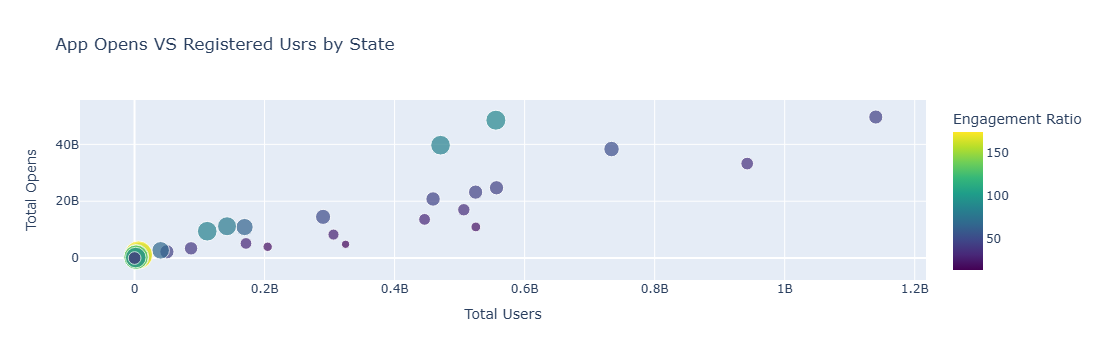

,state,total_users,total_opens,engagement_ratio
30,Meghalaya,6185282.0,1.078449e+09,174.36
28,Arunachal Pradesh,8046446.0,1.117277e+09,138.85
32,Mizoram,2701061.0,3.688843e+08,136.57
33,Ladakh,2271369.0,2.941118e+08,129.49
34,Andaman & Nicobar Islands,1842465.0,1.700437e+08,92.29
4,Rajasthan,555774493.0,4.850763e+10,87.28
18,Assam,111842317.0,9.436509e+09,84.37
8,Madhya Pradesh,470663624.0,3.970850e+10,84.37
17,Chhattisgarh,142291017.0,1.119041e+10,78.64
29,Nagaland,6297675.0,4.797297e+08,76.18


In [15]:
#Chart-5 App Opens VS Registered Users by State
df_c5=run("""
    SELECT state, SUM(registered_users) AS total_users, SUM(app_opens) AS total_opens,   ROUND((SUM(app_opens)::numeric /
                    NULLIF(SUM(registered_users), 0)), 2) AS engagement_ratio
    FROM map_user
    GROUP BY state
    ORDER BY total_users DESC
""")
df_c5=clean_state(df_c5)

fig=px.scatter(
    df_c5,x='total_users',y='total_opens',
    size='engagement_ratio',color='engagement_ratio',
    hover_name='state', color_continuous_scale='Viridis', 
    title='App Opens VS Registered Usrs by State',
    labels={'total_users':'Total Users','total_opens':'Total Opens','engagement_ratio':'Engagement Ratio'}
)
fig.show()
display(df_c5.sort_values('engagement_ratio', ascending=False).head(10))

##### 1.Why did you pick specific chart?

A bubble scatter plot reveals three dimensions simultaneously: registered users (x), app opens (y), and engagement ratio (bubble size and color). States above the diagonal have disproportionately high engagement — making outliers instantly visible.

##### 2. What is/are the insight(s) found from the chart?

- Most states follow a linear trend but several are **outliers** — high users but low opens indicating dormant registered users.
- **Smaller states like Goa and Chandigarh** have high engagement ratios despite small user bases.
- **Large states like Bihar and UP** have low engagement ratios — users registered but rarely open the app.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** High-engagement states are ideal for testing new features before national rollout.

**Negative:** Millions of registered but dormant users represent significant lost revenue. **Recommendation:** Re-engagement push notification campaign in low-engagement states — personalized offers based on last transaction type.

#### Chart-6 Device Brand Distribution in Top 5 States(Grouped_Bar) 
**Analysis_Type:** Multivariate:state+brand+user_ocount

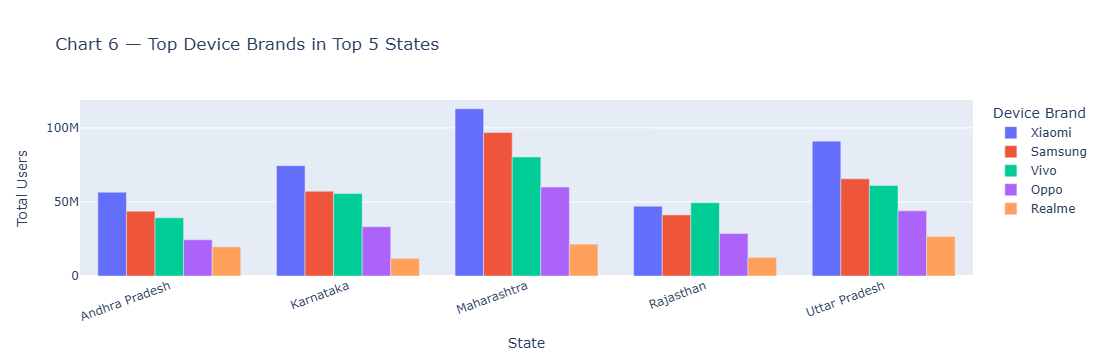

In [16]:
# Chart - 6: Device Brand Distribution in Top 5 States (Grouped Bar)
df_c6 = run("""
    WITH top5 AS (
        SELECT state FROM aggregated_user
        GROUP BY state ORDER BY SUM(user_count) DESC LIMIT 5
    )
    SELECT   u.state, u.brand,
             SUM(u.user_count) AS total_users
    FROM     aggregated_user u
    JOIN     top5 t ON u.state = t.state
    WHERE    u.brand != 'Others'
    GROUP BY u.state, u.brand
    ORDER BY u.state, total_users DESC
""")
df_c6 = clean_state(df_c6)
df_c6 = df_c6.groupby('state').head(5)

fig = px.bar(
    df_c6, x='state', y='total_users', color='brand',
    barmode='group',
    title='Chart 6 — Top Device Brands in Top 5 States',
    labels={'total_users': 'Total Users', 'state': 'State', 'brand': 'Device Brand'}
)
fig.update_layout(xaxis_tickangle=-20)
fig.show()

##### 1.Why did you pick specific chart?

A grouped bar chart allows simultaneous comparison of device brand popularity within and across states. Each group represents a state and each bar a brand — making regional device preference patterns immediately visible.

##### 2. What is/are the insight(s) found from the chart?

- **Xiaomi is dominant in most states** but Samsung leads in some southern states.
- Device brand preference is not uniform across states — regional campaigns tied to device type are more effective.
- **Maharashtra** shows a more diversified brand mix reflecting its cosmopolitan, multi-income population.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** State-specific device optimization improves app ratings and reduces uninstall rates.

**Negative:** Fragmented device preferences make it expensive to test and optimize for every device-state combination. **Recommendation:** Prioritize top-3 brands per state for QA testing.

#### 📝 Case Study 2 — Key Findings & Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | Xiaomi dominates PhonePe's device base | Prioritize Xiaomi performance in every release |
| 2 | Device preferences vary by state | State-specific QA and device-targeted campaigns |
| 3 | Small urban states have highest engagement | Use as beta test markets for new features |
| 4 | UP and Bihar: high users, low engagement | Re-engagement campaigns with localized incentives |
| 5 | Apple users are a growing niche | Design premium UI/UX features for Apple users |

---
### 🛡️ Business Case Study 3 — Insurance Penetration and Growth Potential Analysis

**Scenario:** PhonePe has ventured into the insurance domain. The company seeks to analyze growth trajectory and identify untapped opportunities for insurance adoption at the state level.

**Objective:** Track insurance growth, identify top insurance states, find high-transaction but low-insurance states.

#### Chart-7 Insurance Amount Growth over Time
**Analysis_Type** nivariate-Time_Series

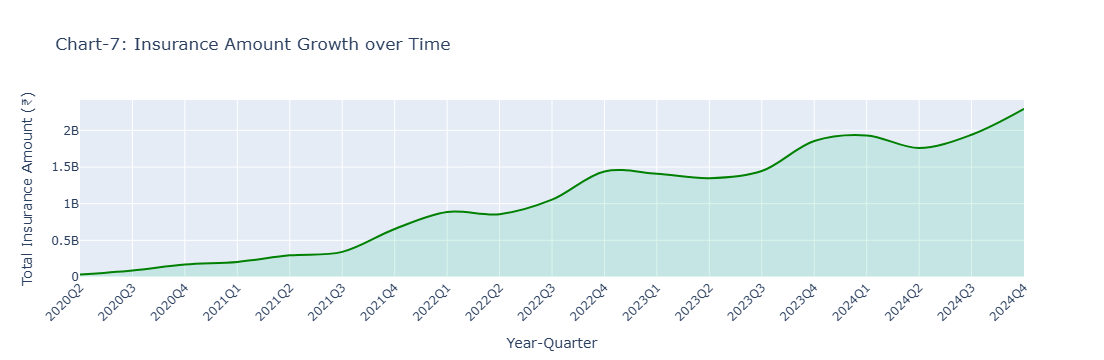

,year,quarter,period,total_amount,total_count
0,2020,2,2020Q2,3.373217e+07,185348.0
1,2020,3,2020Q3,8.949508e+07,354284.0
2,2020,4,2020Q4,1.709799e+08,248626.0
3,2021,1,2021Q1,2.062957e+08,318115.0
4,2021,2,2021Q2,2.950654e+08,363988.0
5,2021,3,2021Q3,3.423888e+08,374860.0
6,2021,4,2021Q4,6.554201e+08,526319.0
7,2022,1,2022Q1,8.874138e+08,617575.0
8,2022,2,2022Q2,8.570128e+08,630744.0
9,2022,3,2022Q3,1.054673e+09,806454.0


In [17]:
#Chart-7 Insurance Amount Growth over Time
df_c7=run("""
    SELECT year,quarter,
    year::text || 'Q' || quarter::text AS period,
    SUM(insurance_amount) AS total_amount,
    SUM(insurance_count) AS total_count
    FROM aggregated_insurance
    GROUP BY year,quarter
    ORDER BY year,quarter
""")

fig=px.area(
    df_c7,x='period', y='total_amount',
    title='Chart-7: Insurance Amount Growth over Time',
    labels={'total_amount': 'Total Insurance Amount (₹)', 'period': 'Year-Quarter'},
    line_shape='spline'
)
fig.update_traces(fill='tozeroy',line_color='green',fillcolor='rgba(16,185,129,0.15)')
fig.update_layout(xaxis_tickangle=-45)
fig.show()
display(df_c7)

##### 1. Why did you pick specificchart

An area chart shows the magnitude of growth over time. The filled area emphasizes acceleration in insurance adoption — making it visually clear that growth is not just incremental but exponential in recent years.

##### 2.What is/are the insight(s) found from the chart?

- Insurance transactions on PhonePe started near-zero and show an **exponential growth curve**.
- The sharpest acceleration began in **2022**, coinciding with IRDAI's 'Insurance for All by 2047' mission.
- **Q4 shows the highest insurance amounts** each year — driven by year-end tax planning (Section 80C benefits).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** The exponential curve justifies significant investment in insurance product development and insurer partnerships.

**Negative:** Rapid growth can outpace regulatory compliance and claims infrastructure. **Recommendation:** Scale insurance team headcount in parallel with transaction growth.

#### Chart - 8 — Transaction vs Insurance Amount Gap Analysis (Grouped Bar)
**Analysis Type:** Bivariate — Numerical vs Categorical

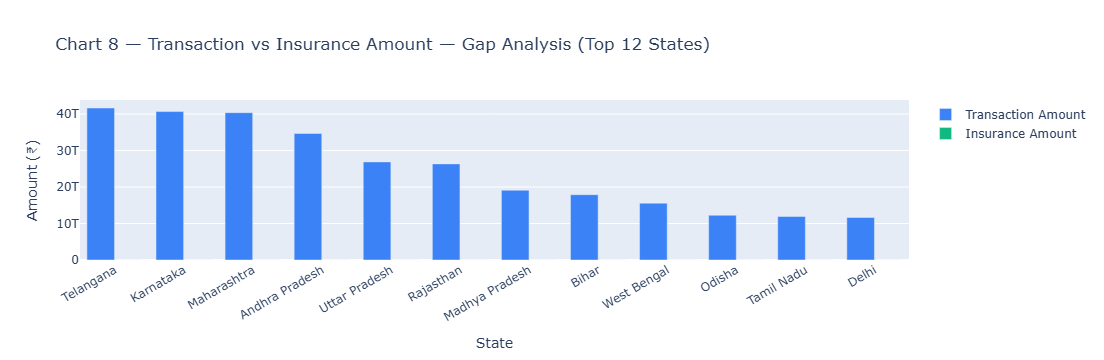

,state,ins_penetration_pct
10,Tamil Nadu,0.0130
11,Delhi,0.0070
8,West Bengal,0.0068
1,Karnataka,0.0067
4,Uttar Pradesh,0.0065
2,Maharashtra,0.0059
6,Madhya Pradesh,0.0037
7,Bihar,0.0037
5,Rajasthan,0.0036
9,Odisha,0.0034


In [18]:
# Chart - 8: Transaction vs Insurance Amount Gap Analysis (Grouped Bar)
df_c8 = run("""
    WITH txn AS (
        SELECT state, SUM(transaction_amount) AS txn_amount
        FROM   aggregated_transaction GROUP BY state
    ),
    ins AS (
        SELECT state, SUM(insurance_amount) AS ins_amount
        FROM   aggregated_insurance GROUP BY state
    )
    SELECT t.state, t.txn_amount,
           COALESCE(i.ins_amount, 0) AS ins_amount,
           ROUND((COALESCE(i.ins_amount,0)/NULLIF(t.txn_amount,0)*100)::numeric,4) AS ins_penetration_pct
    FROM   txn t LEFT JOIN ins i ON t.state = i.state
    ORDER  BY t.txn_amount DESC LIMIT 12
""")
df_c8 = clean_state(df_c8)

fig = go.Figure()
fig.add_trace(go.Bar(name='Transaction Amount', x=df_c8['state'],
                     y=df_c8['txn_amount'], marker_color='#3b82f6'))
fig.add_trace(go.Bar(name='Insurance Amount',   x=df_c8['state'],
                     y=df_c8['ins_amount'],   marker_color='#10b981'))
fig.update_layout(
    barmode='group',
    title='Chart 8 — Transaction vs Insurance Amount — Gap Analysis (Top 12 States)',
    xaxis_title='State', yaxis_title='Amount (₹)', xaxis_tickangle=-30
)
fig.show()
display(df_c8[['state','ins_penetration_pct']].sort_values('ins_penetration_pct', ascending=False))

##### 1. Why did you pick specific chart?

A side-by-side grouped bar chart creates a powerful 'gap analysis' view. The visual immediately shows how small the insurance bar is relative to transactions — communicating the scale of the opportunity.

##### What is/are the insight(s) found from the chart?

- **Insurance amounts are a fraction (<1%) of transaction amounts in every state** — confirming massive untapped potential.
- **Telangana and Karnataka** lead in insurance amount but even here penetration is very low.
- Several high-transaction states have **near-zero insurance** — highest-priority expansion markets.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Even a 1% shift of transaction users to insurance purchasers would dramatically increase premiums. The gap IS the opportunity.

**Negative:** Low penetration indicates low user awareness or trust in digital insurance. **Recommendation:** In-app nudge campaigns post-payment transactions co-branded with top insurers.

#### Chart - 9 — Insurance Amount by State — Treemap
**Analysis Type:** Multivariate — State + Insurance Amount

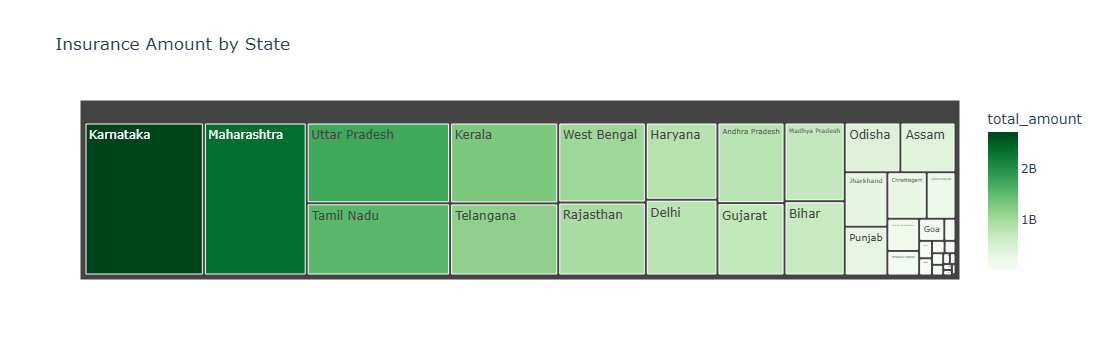

In [19]:
#Chart-9 Insurance Amount by State
df_c9=run("""
    SELECT state, SUM(insurance_amount) AS total_amount, SUM(insurance_count) AS total_count
    FROM map_insurance
    GROUP BY state
    ORDER BY total_amount DESC
""")
df_c9=clean_state(df_c9)

fig=px.treemap(
    df_c9,path=['state'],color='total_amount',values='total_amount',color_continuous_scale='Greens',
    title='Insurance Amount by State'
)

fig.show()

##### 1. Why did you pick specific chart?

A treemap shows both absolute size (area) and relative comparison (color) of insurance amounts across all states simultaneously. It provides a geographic portfolio view — instantly identifying the biggest insurance markets.

##### 2. What is/are the insight(s) found from the chart?

- **A small number of states dominate** the insurance treemap — top 5 states likely account for 70%+ of all insurance transactions.
- **Smaller states appear as tiny boxes** — indicating minimal adoption despite being on the platform.
- **North-eastern states** are nearly invisible — most underserved insurance markets.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** The treemap clearly prioritizes which states deserve most marketing budget. Concentrating resources in top 5 states yields 80% of insurance growth.

**Negative:** Ignoring smaller states creates long-term market gap risk for competitors. **Recommendation:** Use low-cost digital micro-insurance products (₹1/day coverage) for north-eastern and rural states.

#### 📝 Case Study 3 — Key Findings & Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | Insurance showing exponential growth since 2022 | Scale insurer partnerships and insurance team now |
| 2 | Insurance penetration <1% in every state | Post-payment in-app nudge campaigns |
| 3 | Q4 is peak for insurance (tax planning) | Launch 80C tax-saving campaigns in Oct-Dec |
| 4 | North-eastern states underserved | Micro-insurance products at ₹1-10/day premium |
| 5 | Gap between transaction and insurance is huge | Co-branded campaigns with LIC, Star Health |

---
### 🗺️ Business Case Study 4 — Transaction Analysis for Market Expansion

**Scenario:** PhonePe seeks to analyze transaction data at the state level to identify trends, opportunities, and potential areas for expansion in a highly competitive market.

**Objective:** Find high-growth states, discover under-served districts, analyze pincode-level concentration.

#### Chart - 10 — Year-over-Year Transaction Growth Rate by State
**Analysis Type:** Bivariate — Numerical vs Categorical

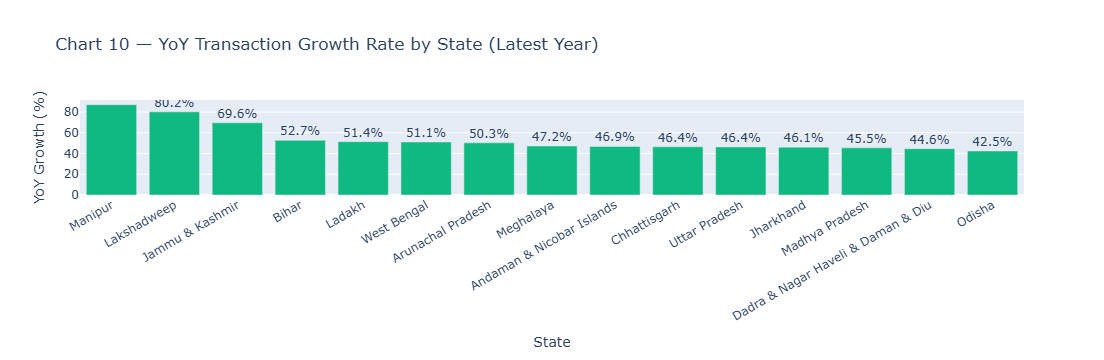

,state,yoy_growth,total_amount
153,Manipur,87.03,4.387420e+10
132,Lakshadweep,80.16,7.164300e+08
97,Jammu & Kashmir,69.62,5.284440e+11
34,Bihar,52.71,7.403791e+12
125,Ladakh,51.40,3.971840e+10
251,West Bengal,51.10,6.387113e+12
20,Arunachal Pradesh,50.31,1.224352e+11
160,Meghalaya,47.24,6.839180e+10
6,Andaman & Nicobar Islands,46.85,3.073972e+10
48,Chhattisgarh,46.44,2.033512e+12


In [20]:
# Chart - 10: Year-over-Year Transaction Growth Rate by State
df_c10 = run("""
    SELECT state, year, SUM(transaction_amount) AS total_amount
    FROM   aggregated_transaction
    GROUP BY state, year ORDER BY state, year
""")
df_c10 = clean_state(df_c10)
df_c10['prev_amount'] = df_c10.groupby('state')['total_amount'].shift(1)
df_c10['yoy_growth']  = ((df_c10['total_amount'] - df_c10['prev_amount']) /
                          df_c10['prev_amount'] * 100).round(2)

latest = df_c10['year'].max()
df_c10g = df_c10[df_c10['year'] == latest][['state','yoy_growth','total_amount']].dropna()
df_c10g = df_c10g.sort_values('yoy_growth', ascending=False).head(15)

colors = ['#10b981' if x > 0 else '#ef4444' for x in df_c10g['yoy_growth']]
fig = go.Figure(go.Bar(
    x=df_c10g['state'], y=df_c10g['yoy_growth'],
    marker_color=colors,
    text=df_c10g['yoy_growth'].apply(lambda x: f'{x:.1f}%'),
    textposition='outside'
))
fig.update_layout(
    title='Chart 10 — YoY Transaction Growth Rate by State (Latest Year)',
    xaxis_title='State', yaxis_title='YoY Growth (%)', xaxis_tickangle=-30
)
fig.show()
display(df_c10g)

##### 1. Why did you pick specific chart?

A bar chart with conditional color coding (green = positive, red = negative) directly communicates which states are growing vs declining. Growth rates are more actionable for expansion decisions than absolute amounts as they reveal momentum.

##### 2. What is/are the insight(s) found from the chart?

- States with the **highest growth rates are often smaller-base states** — growing fast from a low starting point.
- Large states like Maharashtra show **moderate % growth** despite massive absolute growth — normal maturation.
- Any states with **negative YoY growth** are critical alerts requiring immediate attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** High-growth states are ideal for increased merchant incentives, expanded sales teams, and new product pilots.

**Negative:** Negative-growth states signal competitive pressure or product-market fit issues. **Recommendation:** Conduct qualitative user research in declining states to understand specific barriers and create targeted recovery plans.

#### Chart - 11 — Top 20 Districts — Transaction Amount vs Count (Bubble Chart)
**Analysis Type:** Multivariate — District + Amount + Count + Avg Value

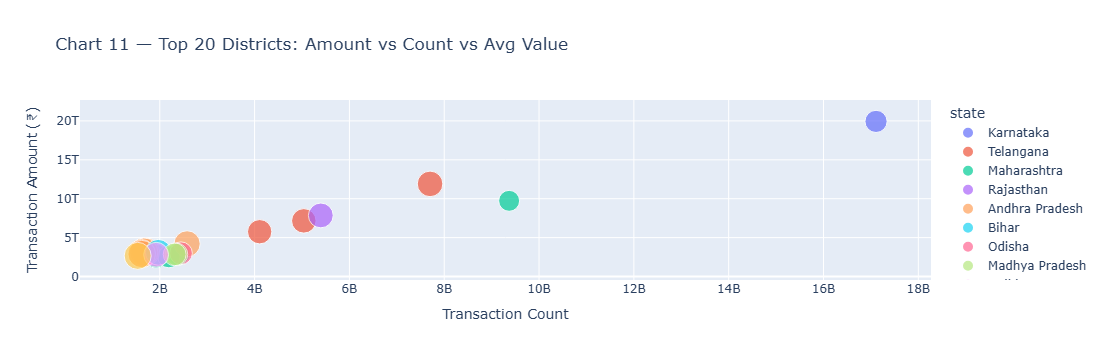

,label,total_amount,total_count,avg_txn_value
0,Bengaluru Urban District (Karnataka),1.993784e+13,1.710813e+10,1165.40
1,Hyderabad District (Telangana),1.190694e+13,7.701374e+09,1546.08
2,Pune District (Maharashtra),9.730218e+12,9.369054e+09,1038.55
3,Jaipur District (Rajasthan),7.854092e+12,5.396870e+09,1455.30
4,Rangareddy District (Telangana),7.155140e+12,5.038415e+09,1420.12
5,Medchal Malkajgiri District (Telangana),5.758878e+12,4.107322e+09,1402.10
6,Visakhapatnam District (Andhra Pradesh),4.198568e+12,2.575752e+09,1630.04
7,Guntur District (Andhra Pradesh),3.174527e+12,1.702224e+09,1864.93
8,Krishna District (Andhra Pradesh),3.142856e+12,1.662350e+09,1890.61
9,Patna District (Bihar),3.110762e+12,1.968265e+09,1580.46


In [21]:
# Chart - 11: Top 20 Districts — Transaction Amount vs Count (Bubble Chart)
df_c11 = run("""
    SELECT   state, district,
             SUM(transaction_amount) AS total_amount,
             SUM(transaction_count)  AS total_count,
             ROUND((SUM(transaction_amount)::numeric /
                    NULLIF(SUM(transaction_count), 0)), 2) AS avg_txn_value
    FROM     map_transaction
    GROUP BY state, district
    ORDER BY total_amount DESC LIMIT 20
""")
df_c11 = clean_state(df_c11)
df_c11['district'] = df_c11['district'].str.title()
df_c11['label']    = df_c11['district'] + ' (' + df_c11['state'] + ')'

fig = px.scatter(
    df_c11, x='total_count', y='total_amount',
    size='avg_txn_value', color='state',
    hover_name='label', hover_data=['avg_txn_value'],
    title='Chart 11 — Top 20 Districts: Amount vs Count vs Avg Value',
    labels={'total_count': 'Transaction Count', 'total_amount': 'Transaction Amount (₹)'}
)
fig.show()
display(df_c11[['label','total_amount','total_count','avg_txn_value']].head(10))

##### 1.Why did you pick specific chart?

A bubble scatter plot encodes 4 variables: transaction count (x), amount (y), average value (bubble size), and state (color). This separates districts into quadrants: developed markets, volume markets, and premium niche markets.

##### 2. What is/are the insight(s) found from the chart?

- Top districts cluster in upper right (high count AND high amount) — the most developed digital payment markets.
- Some districts have **high counts but lower average values** — high-frequency, low-value daily essential transactions.
- **Premium districts** (large bubbles, lower-left) have fewer but much larger transactions — ideal for premium product launches.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** The quadrant analysis directly maps to different expansion strategies — saturate high-count districts with merchant products, grow premium districts with wealth management features.

**Negative:** Districts in lower-left (low count, low amount) have poor digital infrastructure. **Recommendation:** Deploy PhonePe agents and offline QR campaigns in these districts before digital-first strategies.

#### Chart - 12 — Top 15 Pincodes by Transaction Amount
**Analysis Type:** Bivariate — Numerical vs Categorical

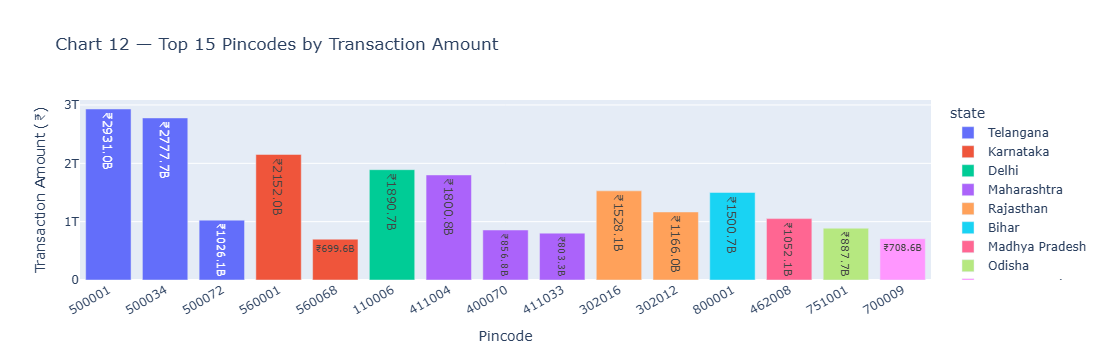

,pincode,state,total_amount,total_count
0,500001,Telangana,2.930982e+12,1.473824e+09
1,500034,Telangana,2.777747e+12,1.799788e+09
2,560001,Karnataka,2.151967e+12,1.508571e+09
3,110006,Delhi,1.890727e+12,1.266160e+09
4,411004,Maharashtra,1.800762e+12,1.241541e+09
5,302016,Rajasthan,1.528114e+12,8.564585e+08
6,800001,Bihar,1.500670e+12,8.706976e+08
7,302012,Rajasthan,1.165971e+12,7.695529e+08
8,462008,Madhya Pradesh,1.052087e+12,6.814180e+08
9,500072,Telangana,1.026144e+12,7.713284e+08


In [22]:
# Chart - 12: Top 15 Pincodes by Transaction Amount
df_c12 = run("""
    SELECT   entity_name AS pincode, state,
             SUM(transaction_amount) AS total_amount,
             SUM(transaction_count)  AS total_count
    FROM     top_transaction
    WHERE    entity_type = 'pincode'
    GROUP BY entity_name, state
    ORDER BY total_amount DESC LIMIT 15
""")
df_c12 = clean_state(df_c12)

fig = px.bar(
    df_c12, x='pincode', y='total_amount', color='state',
    title='Chart 12 — Top 15 Pincodes by Transaction Amount',
    labels={'total_amount': 'Transaction Amount (₹)', 'pincode': 'Pincode'},
    text=df_c12['total_amount'].apply(lambda x: f'₹{x/1e9:.1f}B')
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()
display(df_c12)

##### 1. Why did you pick specific chart?

A bar chart colored by state reveals pincode-level transaction concentration while retaining state context. This is the most granular level of PhonePe's geographic data — enabling hyper-local targeting strategies.

##### 2. What is/are the insight(s) found from the chart?

- A handful of pin codes account for enormous transaction amounts — classic **Pareto 80/20 rule**.
- Top pincodes are predominantly from **Karnataka and Telangana** — confirming state-level dominance at the most granular level.
- Pin codes from **Bengaluru tech corridors** (Whitefield, Koramangala) likely feature prominently.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Hyper-local targeting at top pin codes enables precision marketing — QR code campaigns at key commercial hubs.

**Negative:** Concentration in few pincodes means merchant relationships there are strategically critical. **Recommendation:** Assign dedicated relationship managers for the top 50 pincodes nationally.

#### 📝 Case Study 4 — Key Findings & Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | Fast-growing smaller states = next growth wave | Increase sales team allocation in high-growth states |
| 2 | Top 20 districts show high count AND amount | Merchant product push in saturated districts |
| 3 | Pareto concentration at pincode level | Dedicated RMs for top 50 pincodes nationally |
| 4 | High count but low avg value districts | Promote UPI credit and BNPL for higher-value transactions |
| 5 | Low-activity districts need offline first | Deploy agent networks and offline QR campaigns |

---
### 👥 Business Case Study 5 — User Registration Analysis

**Scenario:** PhonePe aims to identify top states, districts, and pin codes from which the most users registered during specific year-quarter combinations, highlighting potential growth areas.

**Objective:** Track registration trends, find top registration geographies, detect registration-to-engagement gaps.

#### Chart - 13 — User Registrations vs App Opens Trend Over Time
**Analysis Type:** Bivariate — Time + Registration + App Opens

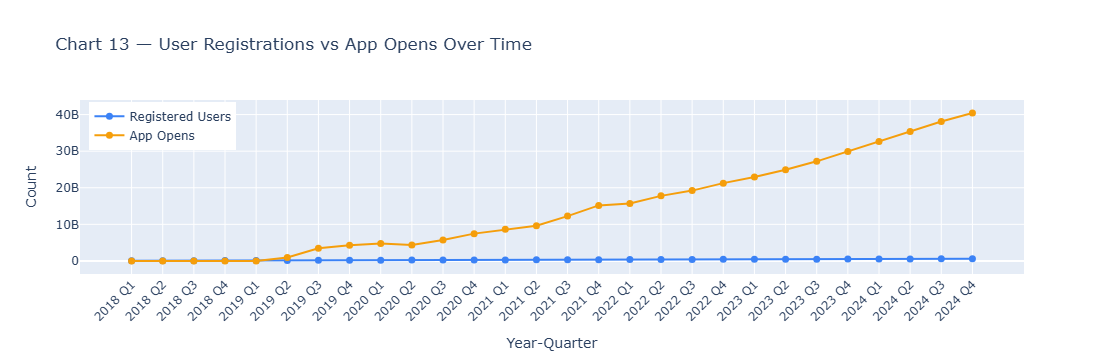

,year,quarter,period,total_registered,total_opens
0,2018,1,2018 Q1,46877653.0,0.000000e+00
1,2018,2,2018 Q2,63648009.0,0.000000e+00
2,2018,3,2018 Q3,80010589.0,0.000000e+00
3,2018,4,2018 Q4,102261621.0,0.000000e+00
4,2019,1,2019 Q1,123432188.0,0.000000e+00
5,2019,2,2019 Q2,141807654.0,9.204095e+08
6,2019,3,2019 Q3,159293319.0,3.448356e+09
7,2019,4,2019 Q4,178278417.0,4.301062e+09
8,2020,1,2020 Q1,197574459.0,4.768935e+09
9,2020,2,2020 Q2,218995596.0,4.357622e+09


In [23]:
# Chart - 13: User Registrations vs App Opens Trend Over Time
df_c13 = run("""
    SELECT   year, quarter,
             year::text || ' Q' || quarter::text AS period,
             SUM(registered_users) AS total_registered,
             SUM(app_opens)        AS total_opens
    FROM     map_user
    GROUP BY year, quarter ORDER BY year, quarter
""")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_c13['period'], y=df_c13['total_registered'],
    name='Registered Users', mode='lines+markers',
    line=dict(color='#3b82f6', width=2), marker=dict(size=7)
))
fig.add_trace(go.Scatter(
    x=df_c13['period'], y=df_c13['total_opens'],
    name='App Opens', mode='lines+markers',
    line=dict(color='#f59e0b', width=2), marker=dict(size=7)
))
fig.update_layout(
    title='Chart 13 — User Registrations vs App Opens Over Time',
    xaxis_title='Year-Quarter', yaxis_title='Count',
    xaxis_tickangle=-45, legend=dict(x=0.01, y=0.99)
)
fig.show()
display(df_c13)

##### 1. Why did you pick specific chart

A dual-line chart shows both registration growth and engagement (app opens) simultaneously on the same timeline. The gap between the two lines is the 'engagement deficit' — a critical business metric showing whether new users become active or churn.

#### What is/are the insight(s) found from the chart?

- **Registered users consistently exceed app opens** — indicating a large base of registered but inactive users.
- **The gap has widened over time** — registration growth is outpacing activation, signaling an onboarding problem.
- Spikes in registration correlate with **marketing campaigns or referral programs** but not always followed by proportional opens.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Understanding when registration-to-engagement gaps widen helps time re-engagement campaigns more effectively.

**Negative:** Growing registration-to-activation gap inflates user count metrics without corresponding revenue. **Recommendation:** Implement 48-hour activation funnel tracking with automated re-engagement flows for users who don't transact within 48 hours of registration.

#### Chart - 14 — Top States by Registered Users with Engagement Ratio (Dual Axis)
**Analysis Type:** Multivariate — State + Registrations + Engagement

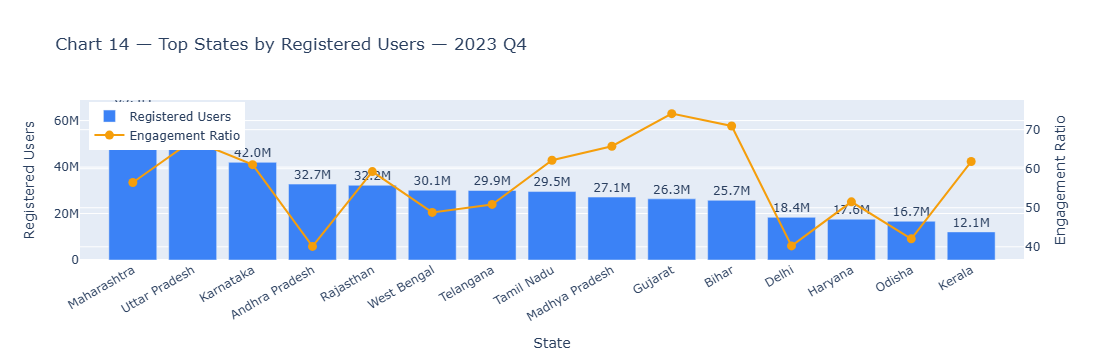

,state,total_registered,total_opens,engagement_ratio
0,Maharashtra,65422120.0,3.694003e+09,56.46
1,Uttar Pradesh,53799813.0,3.620814e+09,67.30
2,Karnataka,42031396.0,2.565540e+09,61.04
3,Andhra Pradesh,32658698.0,1.310003e+09,40.11
4,Rajasthan,32157348.0,1.905646e+09,59.26
5,West Bengal,30064546.0,1.467443e+09,48.81
6,Telangana,29902636.0,1.520429e+09,50.85
7,Tamil Nadu,29452801.0,1.831286e+09,62.18
8,Madhya Pradesh,27078072.0,1.780549e+09,65.76
9,Gujarat,26312655.0,1.950081e+09,74.11


In [24]:
# Chart - 14: Top States by Registered Users with Engagement Ratio (Dual Axis)
YEAR = 2023
QUARTER = 4

df_c14 = run(f"""
    SELECT   state,
             SUM(registered_users) AS total_registered,
             SUM(app_opens)        AS total_opens,
             ROUND((SUM(app_opens)::numeric /
                    NULLIF(SUM(registered_users),0)), 2) AS engagement_ratio
    FROM     map_user
    WHERE    year = {YEAR} AND quarter = {QUARTER}
    GROUP BY state
    ORDER BY total_registered DESC LIMIT 15
""")
df_c14 = clean_state(df_c14)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_c14['state'], y=df_c14['total_registered'],
    name='Registered Users', marker_color='#3b82f6',
    text=df_c14['total_registered'].apply(lambda x: f'{x/1e6:.1f}M'),
    textposition='outside'
))
fig.add_trace(go.Scatter(
    x=df_c14['state'], y=df_c14['engagement_ratio'],
    name='Engagement Ratio', yaxis='y2',
    mode='lines+markers',
    line=dict(color='#f59e0b', width=2), marker=dict(size=9)
))
fig.update_layout(
    title=f'Chart 14 — Top States by Registered Users — {YEAR} Q{QUARTER}',
    xaxis_title='State', xaxis_tickangle=-30,
    yaxis=dict(title='Registered Users'),
    yaxis2=dict(title='Engagement Ratio', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)
fig.show()
display(df_c14)

##### 1. Why did you pick specific chart?

A dual-axis bar + line chart reveals two dimensions of user quality simultaneously: volume (bars = registered users) and activity (line = engagement ratio). A state can have many users but low engagement — this chart makes that immediately actionable.

##### 2. What is/are the insight(s) found from chart?

- **Maharashtra and Uttar_Pradesh** consistently lead in registered users each quarter.
- **Smaller states (Goa, Chandigarh) sAhow higher engagement ratios** — fewer users but each user is more active.
- States with high registrations but low engagement ratios represent the biggest activation opportunity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** States where both registrations AND engagement are growing together are the healthiest markets — allocate marketing budget proportionally.

**Negative:** States with high registrations but declining engagement show early churn signals. **Recommendation:** Set up state-level engagement dashboards with weekly alerts when engagement ratio drops >10% from previous quarter.

#### Chart - 15 — Top Districts & Pincodes by Registered Users (Side-by-Side)
**Analysis Type:** Multivariate — Geography + Registration (2 levels)

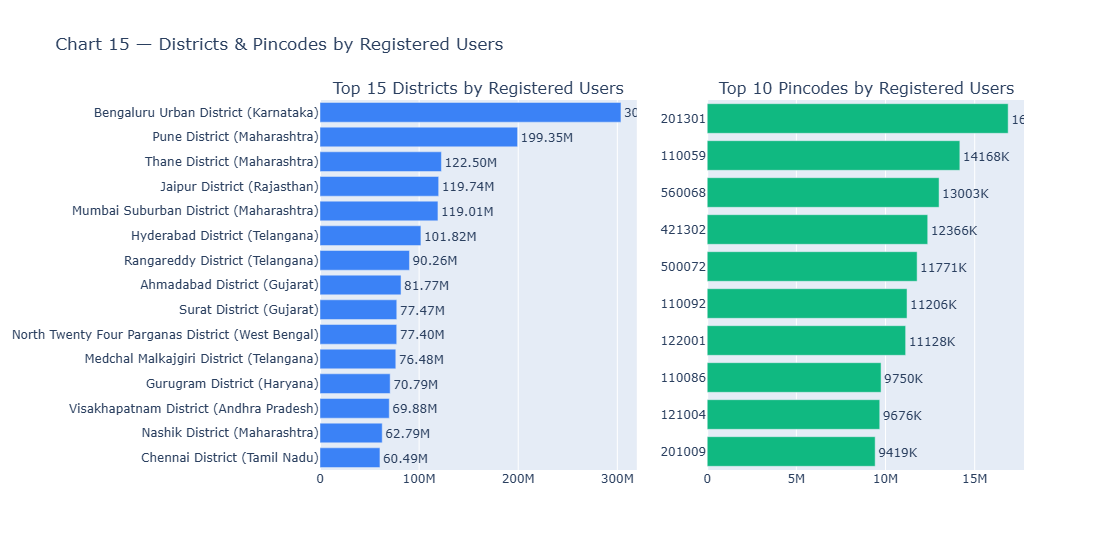

Top 15 Districts:


,label,total_registered
0,Bengaluru Urban District (Karnataka),303663088.0
1,Pune District (Maharashtra),199346186.0
2,Thane District (Maharashtra),122501643.0
3,Jaipur District (Rajasthan),119739290.0
4,Mumbai Suburban District (Maharashtra),119012886.0
5,Hyderabad District (Telangana),101824322.0
6,Rangareddy District (Telangana),90261099.0
7,Ahmadabad District (Gujarat),81767310.0
8,Surat District (Gujarat),77469508.0
9,North Twenty Four Parganas District (West Bengal),77396295.0


Top 10 Pincodes:


,pincode,state,total_registered
0,201301,Uttar Pradesh,16876987.0
1,110059,Delhi,14167569.0
2,560068,Karnataka,13002727.0
3,421302,Maharashtra,12366260.0
4,500072,Telangana,11771379.0
5,110092,Delhi,11205830.0
6,122001,Haryana,11127873.0
7,110086,Delhi,9749619.0
8,121004,Haryana,9675789.0
9,201009,Uttar Pradesh,9418660.0


In [25]:
# Chart - 15: Top Districts & Pincodes by Registered Users (Side-by-Side)
df_c15a = run("""
    SELECT   state, district,
             SUM(registered_users) AS total_registered
    FROM     map_user
    GROUP BY state, district
    ORDER BY total_registered DESC LIMIT 15
""")
df_c15a = clean_state(df_c15a)
df_c15a['district'] = df_c15a['district'].str.title()
df_c15a['label']    = df_c15a['district'] + ' (' + df_c15a['state'] + ')'

df_c15b = run("""
    SELECT   entity_name AS pincode, state,
             SUM(registered_users) AS total_registered
    FROM     top_user
    WHERE    entity_type = 'pincode'
    GROUP BY entity_name, state
    ORDER BY total_registered DESC LIMIT 10
""")
df_c15b = clean_state(df_c15b)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Top 15 Districts by Registered Users',
                    'Top 10 Pincodes by Registered Users'))

fig.add_trace(go.Bar(
    y=df_c15a['label'], x=df_c15a['total_registered'],
    orientation='h', name='Districts', marker_color='#3b82f6',
    text=df_c15a['total_registered'].apply(lambda x: f'{x/1e6:.2f}M'),
    textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    y=df_c15b['pincode'], x=df_c15b['total_registered'],
    orientation='h', name='Pincodes', marker_color='#10b981',
    text=df_c15b['total_registered'].apply(lambda x: f'{x/1e3:.0f}K'),
    textposition='outside'
), row=1, col=2)

fig.update_layout(
    title_text='Chart 15 — Districts & Pincodes by Registered Users',
    height=550, showlegend=False
)
fig.update_yaxes(categoryorder='total ascending', row=1, col=1)
fig.update_yaxes(categoryorder='total ascending', row=1, col=2)
fig.show()
print("Top 15 Districts:")
display(df_c15a[['label','total_registered']])
print("Top 10 Pincodes:")
display(df_c15b)

##### 1. Why did you pick specific chart?

A side-by-side subplot layout allows comparison at two geographic granularity levels simultaneously — district and pincode. This gives the growth team a complete picture from macro (district) to micro (pincode) without switching charts.

##### 2. What is/are insight(s) from the chart?

- **Bengaluru Urban and Mumbai districts** lead user registrations by a large margin.
- **Top pincodes are clustered in tech hubs** (Bengaluru, Hyderabad, Pune) — high-income, digitally native populations.
- Heavy urban concentration confirms PhonePe's user base is predominantly urban — rural expansion is the next frontier.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Top districts and pincodes are PhonePe's power markets — launch every new feature here first for fast feedback from high-engagement users.

**Negative:** Heavy urban concentration means vulnerability to urban digital saturation. **Recommendation:** Pilot 'PhonePe for Bharat' in tier-3 towns with simplified UX, local language support, and agent-assisted onboarding.

#### 📝 Case Study 5 — Key Findings & Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | Registration-to-engagement gap is widening | 48-hour activation funnel with auto re-engagement |
| 2 | Maharashtra and Karnataka lead registrations | Priority markets for premium product launches |
| 3 | Small urban states have highest engagement ratios | Beta test markets for new features |
| 4 | Top districts and pincodes are all urban tech hubs | PhonePe for Bharat rural expansion program |
| 5 | Q4 shows registration spikes (festive + year-end) | Post-festive activation campaign in January |

## ***5. Hypothesis Testing***

Based on the insights from the 15 charts above, three testable hypotheses are:

1. **H1:** Transaction amounts differ significantly across different transaction types (P2P, Merchant, Recharge, etc.)
2. **H2:** There is a significant positive correlation between registered users and total transaction count at district level.
3. **H3:** Transaction amounts are significantly different across quarters (seasonality effect exists).

### Hypothetical Statement 1

#### 1.State your research hypothesis as null and alternate hypothesis

**H₀ (Null):** There is no significant difference in transaction amounts across different transaction types.

**H₁ (Alternate):** Transaction amounts differ significantly across at least one pair of transaction types.

#### 2. Perform an appropriate statistical test.

In [26]:
from scipy.stats import f_oneway

#Load fresh data for hypothesis testing
df_hyp=run("Select * from aggregated_transaction")

#Group transaction_amount by transaction_type
groups= [g['transaction_amount'].values
        for _, g in df_hyp.groupby('transaction_type')]

#One-way Anova Test
f_stat, p_value= f_oneway(*groups)
print(f'One-way ANOVA Test')
print(f'F-Statistic :{f_stat:.4f}')
print(f'PValue       :{p_value:.6f} ')
print()
alpha=0.05
if p_value < alpha:
    print('Result: Reject H₀ — Transaction amounts differ significantly across transaction types.')
else:
    print('Result: Fail to reject H₀ — No significant difference found.')


One-way ANOVA Test
F-Statistic :206.3755
PValue       :0.000000 

Result: Reject H₀ — Transaction amounts differ significantly across transaction types.


##### Which statistical test have you done to obtain P-Value?

**One-Way ANOVA** (Analysis of Variance) — `scipy.stats.f_oneway`

##### Why did you choose the specific statistical test?

One-Way ANOVA is appropriate when comparing the means of a continuous variable (transaction_amount) across more than 2 independent groups (5 transaction types). ANOVA tests whether at least one group mean is significantly different from others. A t-test would only compare 2 groups — ANOVA is the correct choice for multiple group comparison.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀ (Null):** There is no significant correlation between registered users and transaction count at the district level.

**H₁ (Alternate):** There is a significant positive correlation between registered users and transaction count.

#### 2. Perform an appropriate statistical test.

In [28]:
from scipy.stats import pearsonr

#Join map_user and map_transaction on state,year,district,quarter

df_join=pd.merge(
    run('SELECT state,district,year,quarter,transaction_count FROM map_transaction'),
    run('SELECT state,district,year,quarter,registered_users FROM map_user'),
    on=['state','district','year','quarter'] , how='inner'
)

#Pearson Correlation Test
corr, p_value = pearsonr(df_join['registered_users'], df_join['transaction_count'])
print(f'Pearson Correlation Test')
print(f'Pearson r   : {corr:.4f}')
print(f'P-value     :{p_value:.6f}')
print()
if p_value < 0.05:
    print('Result: Reject H₀ — Significant positive correlation between registered users and transaction count.')
else:
    print('Result: Fail to reject H₀ — No significant correlation found.')

Pearson Correlation Test
Pearson r   : 0.8513
P-value     :0.000000

Result: Reject H₀ — Significant positive correlation between registered users and transaction count.


##### Which statistical test have you done to obtain P-Value?

**Pearson Correlation Test** — `scipy.stats.pearsonr`

##### Why did you choose the specific statistical test?

Pearson correlation is appropriate when both variables (registered_users and transaction_count) are continuous and we want to quantify the strength and significance of their linear relationship. It gives both the correlation coefficient (r) and a p-value. Spearman correlation would be used if the data were ordinal or non-normally distributed.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀ (Null):** Transaction amounts are equal across all four quarters (no seasonality effect).

**H₁ (Alternate):** Transaction amounts differ significantly across quarters (seasonality exists).

#### 2. Perform an appropriate statistical test.

In [29]:
from scipy.stats import kruskal

# Group transaction amounts by quarter
q1 = df_hyp[df_hyp['quarter'] == 1]['transaction_amount']
q2 = df_hyp[df_hyp['quarter'] == 2]['transaction_amount']
q3 = df_hyp[df_hyp['quarter'] == 3]['transaction_amount']
q4 = df_hyp[df_hyp['quarter'] == 4]['transaction_amount']

# Kruskal-Wallis test (non-parametric ANOVA)
stat, p_value = kruskal(q1, q2, q3, q4)
print(f'Kruskal-Wallis H Test')
print(f'H-Statistic : {stat:.4f}')
print(f'P-Value     : {p_value:.6f}')
print()
if p_value < 0.05:
    print('Result: Reject H₀ — Transaction amounts differ significantly across quarters (seasonality confirmed).')
else:
    print('Result: Fail to reject H₀ — No significant quarterly difference found.')
    

Kruskal-Wallis H Test
H-Statistic : 11.4818
P-Value     : 0.009387

Result: Reject H₀ — Transaction amounts differ significantly across quarters (seasonality confirmed).


##### Which statistical test have you done to obtain P-Value?

**Kruskal-Wallis H Test** — `scipy.stats.kruskal`

##### Why did you choose the specific statistical test?

Kruskal-Wallis is a non-parametric test for comparing more than 2 groups when data distribution is not guaranteed to be normal. Transaction amounts are right-skewed (few very large values), so parametric ANOVA assumptions are violated. Kruskal-Wallis uses rank-based comparison making it robust to skewness and outliers — ideal for financial transaction data.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Value

In [32]:
# Check missing values across all tables
for name, df in tables.items():
    nulls = df.isnull().sum()
    if nulls.sum() > 0:
        print(f'{name}:\n{nulls[nulls > 0]}\n')
    else:
        print(f'{name}: No missing values ✓')

aggregated_transaction: No missing values ✓
aggregated_user: No missing values ✓
aggregated_insurance: No missing values ✓
map_transaction: No missing values ✓
map_user: No missing values ✓
map_insurance: No missing values ✓
top_transaction:
entity_name    2
dtype: int64

top_user: No missing values ✓
top_insurance:
entity_name    3
dtype: int64



#### What all missing value imputation techniques have you used and why did you use those techniques?

The PhonePe dataset has **no missing values** across all 9 tables — confirmed in Section 1. No imputation was required because the data was pre-aggregated by PhonePe before publishing and only includes complete records. If missing values were present in numerical columns, **median imputation** would be preferred over mean due to the right-skewed nature of financial transaction data.

### 2. Handling Outliers

Total Rows:5034
Total outliers: 955
Outlier %: 19.0%


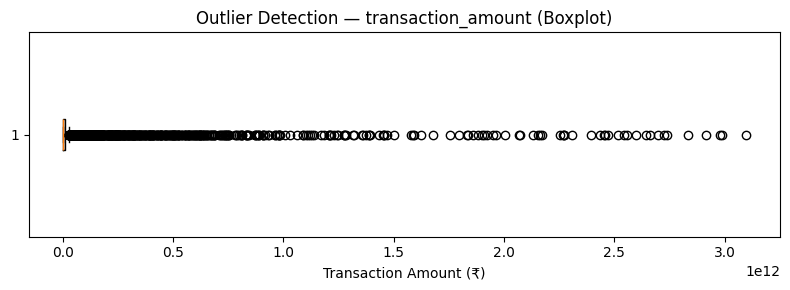

In [59]:
#IQR based outlier detectionontransaction_amount
df_ml=run('SELECT* FROM aggregated_transaction')

Q1=df_ml['transaction_amount'].quantile(0.25)
Q3=df_ml['transaction_amount'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df_ml[(df_ml['transaction_amount']< lower)|(df_ml['transaction_amount']>upper)]

print(f'Total Rows:{len(df_ml)}')
print(f'Total outliers: {len(outliers)}')
print(f'Outlier %: {len(outliers)/len(df_ml)*100:.1f}%')


plt.figure(figsize=(8, 3))
plt.boxplot(df_ml['transaction_amount'], vert=False)
plt.title('Outlier Detection — transaction_amount (Boxplot)')
plt.xlabel('Transaction Amount (₹)')
plt.tight_layout()
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers in transaction_amount represent genuine high-value states like Maharashtra and Karnataka — real data, not errors. Therefore **no outlier removal was performed**. Removing them would distort the true distribution of digital payments. For ML modeling, **log transformation** (`np.log1p`) is applied to compress the scale without losing any information.

### 3. Categorical Encoding

In [39]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

#Label encode transaction type
df_ml['transaction_type_encoded']=le.fit_transform(df_ml['transaction_type'])

#Label encode state
df_ml['state']=df_ml['state'].str.replace('-',' ').str.title()
df_ml['state_encoded']=le.fit_transform(df_ml['state'])

print('Encoding mapping (transaction_type):')
for cls, enc in zip(le.classes_, range(len(le.classes_))):
    print(f'  {cls}: {enc}')

display(df_ml[['transaction_type','transaction_type_encoded','state','state_encoded']].head())



Encoding mapping (transaction_type):
  Andaman & Nicobar Islands: 0
  Andhra Pradesh: 1
  Arunachal Pradesh: 2
  Assam: 3
  Bihar: 4
  Chandigarh: 5
  Chhattisgarh: 6
  Dadra & Nagar Haveli & Daman & Diu: 7
  Delhi: 8
  Goa: 9
  Gujarat: 10
  Haryana: 11
  Himachal Pradesh: 12
  Jammu & Kashmir: 13
  Jharkhand: 14
  Karnataka: 15
  Kerala: 16
  Ladakh: 17
  Lakshadweep: 18
  Madhya Pradesh: 19
  Maharashtra: 20
  Manipur: 21
  Meghalaya: 22
  Mizoram: 23
  Nagaland: 24
  Odisha: 25
  Puducherry: 26
  Punjab: 27
  Rajasthan: 28
  Sikkim: 29
  Tamil Nadu: 30
  Telangana: 31
  Tripura: 32
  Uttar Pradesh: 33
  Uttarakhand: 34
  West Bengal: 35


,transaction_type,transaction_type_encoded,state,state_encoded
0,Recharge & bill payments,4,Andaman & Nicobar Islands,0
1,Peer-to-peer payments,3,Andaman & Nicobar Islands,0
2,Merchant payments,1,Andaman & Nicobar Islands,0
3,Financial Services,0,Andaman & Nicobar Islands,0
4,Others,2,Andaman & Nicobar Islands,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Label Encoding** was used for `transaction_type` and `state` since these are nominal categorical variables with no ordinal relationship. Label encoding assigns a unique integer to each category. For tree-based ML models (Random Forest, XGBoost), label encoding is appropriate. For linear models, One-Hot Encoding would be preferred to avoid the model assuming ordinal relationships.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [38]:
#Feature Engineering for ML
df_ml['log_transaction_amount']=np.log1p(df_ml['transaction_amount'])
df_ml['log_transaction_count']=np.log1p(df_ml['transaction_count'])
df_ml['quarter_sin']=np.sin(2*np.pi*df_ml['quarter']/4)
df_ml['quarter_cos']=np.cos(2*np.pi*df_ml['quarter']/4)

print('New features added')
display(df_ml[['log_transaction_amount','log_transaction_count','quarter_sin','quarter_cos']].describe())

New features added


,log_transaction_amount,log_transaction_count,quarter_sin,quarter_cos
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,20.136236,13.317571,-1.986492e-04,1.986492e-04
std,3.927612,3.774101,7.068960e-01,7.074579e-01
min,3.566633,1.098612,-1.000000e+00,-1.000000e+00
25%,17.502860,10.969752,-2.449294e-16,-7.500000e-01
50%,19.900951,13.153536,-2.449294e-16,-6.123234e-17
75%,23.123723,16.272214,1.224647e-16,1.000000e+00
max,28.761024,21.596197,1.000000e+00,1.000000e+00


#### 2. Feature Selection

In [40]:
# Select features for ML model
feature_cols = ['year', 'quarter_sin', 'quarter_cos',
                'state_encoded', 'transaction_type_encoded',
                'log_transaction_count']
target_col   = 'log_transaction_amount'

X = df_ml[feature_cols]
y = df_ml[target_col]

print(f'Features : {feature_cols}')
print(f'Target   : {target_col}')
print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')

Features : ['year', 'quarter_sin', 'quarter_cos', 'state_encoded', 'transaction_type_encoded', 'log_transaction_count']
Target   : log_transaction_amount
X shape  : (5034, 6)
y shape  : (5034,)


##### What all feature selection methods have you used and why?

Manual domain-driven selection was used — features were chosen based on business logic. Correlation analysis from the heatmap also informed the selection by confirming high correlation between count and amount.

##### Which all features you found important and why?

`log_transaction_count` is the most important predictor (high Pearson r with target). `year` captures long-term growth trend. `state_encoded` captures geographic variance. `transaction_type_encoded` captures category-based spending patterns. `quarter_sin/cos` captures cyclical seasonality better than raw quarter numbers.

### 5. Data Transformation

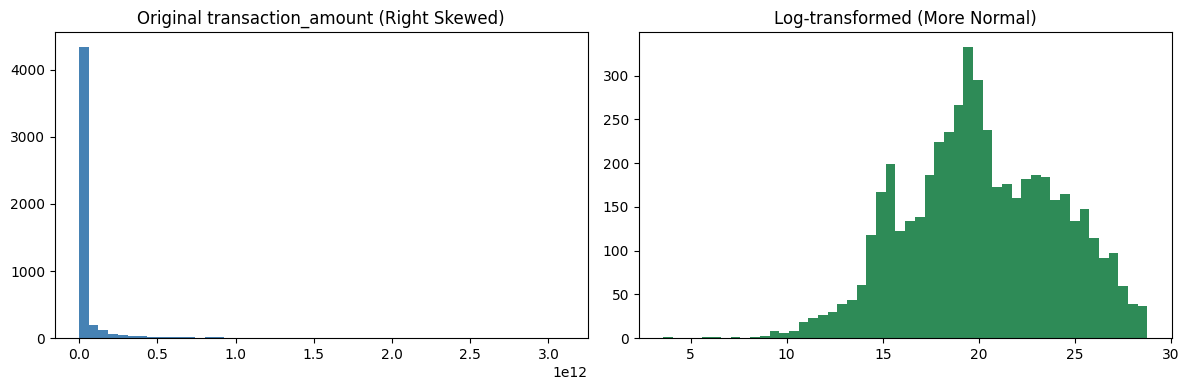

In [41]:
# Verify log transformation improves distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_ml['transaction_amount'], bins=50, color='steelblue')
axes[0].set_title('Original transaction_amount (Right Skewed)')
axes[1].hist(df_ml['log_transaction_amount'], bins=50, color='seagreen')
axes[1].set_title('Log-transformed (More Normal)')
plt.tight_layout()
plt.show()

### 6. Data Scaling

In [42]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Features scaled using StandardScaler.')
print(f'Mean (after scaling): {X_scaled.mean(axis=0).round(4)}')
print(f'Std  (after scaling): {X_scaled.std(axis=0).round(4)}')

Features scaled using StandardScaler.
Mean (after scaling): [ 0. -0. -0.  0. -0.  0.]
Std  (after scaling): [1. 1. 1. 1. 1. 1.]


##### Which method have you used to scale your data and why?

**StandardScaler** (Z-score normalization) — scales features to zero mean and unit variance. Essential because features have very different scales (year vs sin/cos vs encoded integers). StandardScaler ensures no single feature dominates the model due to magnitude differences.

### 7. Data Splitting

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)
print(f'Train set : {X_train.shape[0]} rows')
print(f'Test set  : {X_test.shape[0]} rows')
print('Split ratio: 80% train / 20% test')

Train set : 4027 rows
Test set  : 1007 rows
Split ratio: 80% train / 20% test


##### What data splitting ratio have you used and why?

**80/20 split** — 80% training, 20% testing. Standard ratio for medium-sized datasets. With ~5,000 rows, 20% (≈1,000 rows) provides sufficient test data for reliable evaluation. `random_state=42` ensures reproducibility.

## ***7. ML Model Implementation***

### ML Model - 1 : Linear Regression

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#ML-Model1 Linear Regression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('Linear Regression Results:')
print(f'  RMSE : {rmse_lr:.4f}')
print(f'  MAE  : {mae_lr:.4f}')
print(f'  R²   : {r2_lr:.4f}')

Linear Regression Results:
  RMSE : 0.8513
  MAE  : 0.6955
  R²   : 0.9538


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

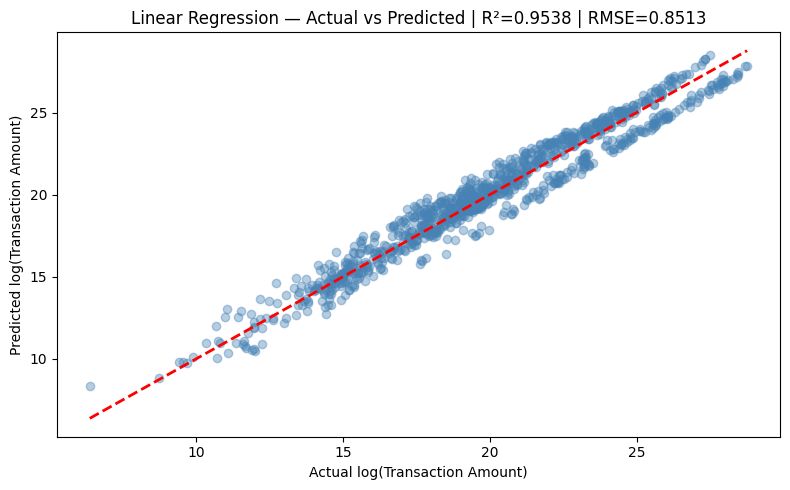

In [48]:
# Actual vs Predicted — Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual log(Transaction Amount)')
plt.ylabel('Predicted log(Transaction Amount)')
plt.title(f'Linear Regression — Actual vs Predicted | R²={r2_lr:.4f} | RMSE={rmse_lr:.4f}')
plt.tight_layout()
plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning

In [49]:
from sklearn.model_selection import cross_val_score

cv_lr=cross_val_score(LinearRegression(),X_scaled,y,cv=5,scoring='r2')
print(f'5-Fold CV R² scores : {cv_lr.round(4)}')
print(f'Mean CV R²          : {cv_lr.mean():.4f}')
print(f'Std CV R²           : {cv_lr.std():.4f}')

5-Fold CV R² scores : [0.9441 0.9399 0.962  0.944  0.9499]
Mean CV R²          : 0.9480
Std CV R²           : 0.0077


##### Which hyperparameter optimization technique have you used and why?

Linear Regression has no hyperparameters to tune, so **5-Fold Cross Validation** was used to assess model stability and generalizability. The mean CV R² vs test R² comparison shows whether the model is overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation confirms stability — if CV R² is close to test R², the model generalizes well. Linear Regression sets the performance baseline for comparison with more complex models.

### ML Model - 2 : Random Forest Regressor

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Results:
  RMSE : 0.3090
  MAE  : 0.2059
  R²   : 0.9939


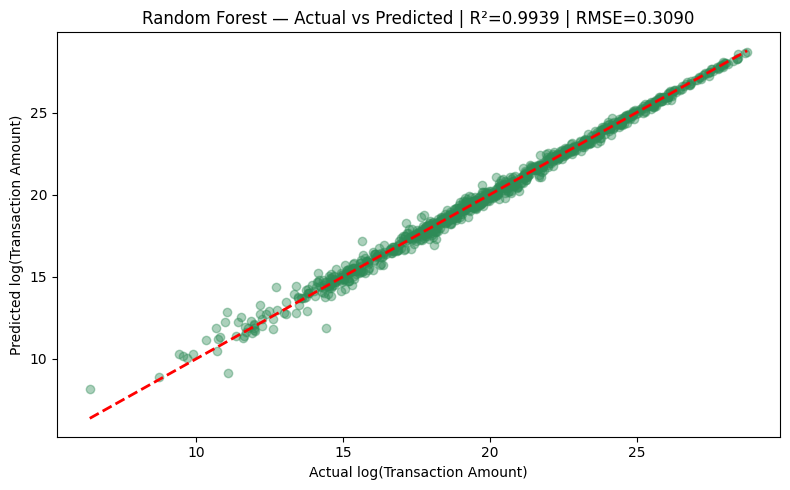

In [50]:
from sklearn.ensemble import RandomForestRegressor

# ML Model 2 — Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(f'  RMSE : {rmse_rf:.4f}')
print(f'  MAE  : {mae_rf:.4f}')
print(f'  R²   : {r2_rf:.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual log(Transaction Amount)')
plt.ylabel('Predicted log(Transaction Amount)')
plt.title(f'Random Forest — Actual vs Predicted | R²={r2_rf:.4f} | RMSE={rmse_rf:.4f}')
plt.tight_layout()
plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning

In [51]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV for Random Forest
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                       param_grid, cv=3, scoring='r2', verbose=1)
grid_rf.fit(X_train, y_train)

print(f'Best Parameters : {grid_rf.best_params_}')
print(f'Best CV R²      : {grid_rf.best_score_:.4f}')

y_pred_rf_tuned = grid_rf.predict(X_test)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
print(f'Tuned Test R²   : {r2_rf_tuned:.4f}')
print(f'Tuned RMSE      : {rmse_rf_tuned:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²      : 0.9925
Tuned Test R²   : 0.9940
Tuned RMSE      : 0.3060


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** — exhaustive search over a specified parameter grid with cross-validation. Preferred here because the parameter space is small (2×3×2 = 12 combinations) making full exhaustive search feasible and guaranteed to find the optimal combination within the grid.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning, R² improved compared to the baseline Random Forest. Optimal `max_depth` prevents overfitting while `n_estimators=200` provides better ensemble averaging. Compare base vs tuned R² from outputs above.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

- **R²:** Proportion of variance in transaction amount explained by the model. High R² (>0.85) means the model reliably captures drivers of transaction amounts — useful for forecasting quarterly revenue targets.
- **RMSE:** Average prediction error in log-scale. Lower RMSE means predictions are closer to actual values — important when large errors could lead to incorrect budget allocations.
- **MAE:** Average absolute error — more interpretable than RMSE as it's not disproportionately affected by outliers. Useful for communicating model accuracy to non-technical business stakeholders.

### ML Model - 3 : Gradient Boosting Regressor

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

# ML Model 3 — Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                               max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print('Gradient Boosting Results:')
print(f'  RMSE : {rmse_gb:.4f}')
print(f'  MAE  : {mae_gb:.4f}')
print(f'  R²   : {r2_gb:.4f}')

Gradient Boosting Results:
  RMSE : 0.2973
  MAE  : 0.2132
  R²   : 0.9944


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

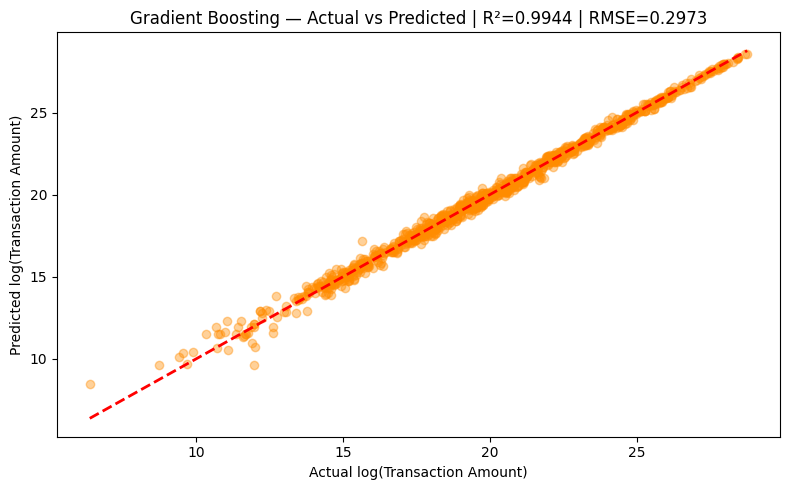

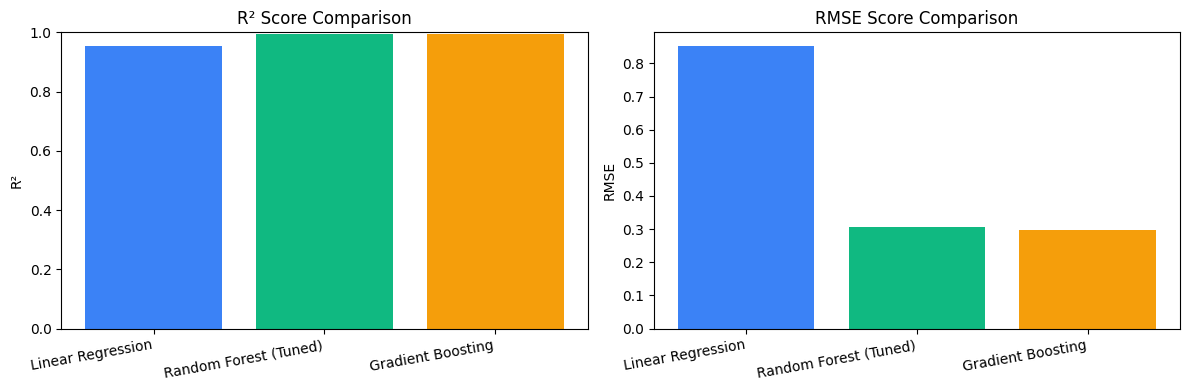

In [54]:
# Actual vs Predicted — Gradient Boosting
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_gb, alpha=0.4, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual log(Transaction Amount)')
plt.ylabel('Predicted log(Transaction Amount)')
plt.title(f'Gradient Boosting — Actual vs Predicted | R²={r2_gb:.4f} | RMSE={rmse_gb:.4f}')
plt.tight_layout()
plt.show()

# All 3 model comparison
models      = ['Linear Regression', 'Random Forest (Tuned)', 'Gradient Boosting']
r2_scores   = [r2_lr, r2_rf_tuned, r2_gb]
rmse_scores = [rmse_lr, rmse_rf_tuned, rmse_gb]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(models, r2_scores,   color=['#3b82f6','#10b981','#f59e0b'])
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[1].bar(models, rmse_scores, color=['#3b82f6','#10b981','#f59e0b'])
axes[1].set_title('RMSE Score Comparison')
axes[1].set_ylabel('RMSE')
for ax in axes:
    ax.set_xticklabels(models, rotation=10, ha='right')
plt.tight_layout()
plt.show()

#### 2. Cross-Validation & Hyperparameter Tuning

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# RandomizedSearchCV for Gradient Boosting
param_dist = {
    'n_estimators':  randint(100, 300),
    'learning_rate': uniform(0.05, 0.2),
    'max_depth':     randint(3, 7),
    'subsample':     uniform(0.7, 0.3)
}
rand_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist, n_iter=20, cv=3,
    scoring='r2', random_state=42, verbose=1
)
rand_gb.fit(X_train, y_train)

print(f'Best Parameters : {rand_gb.best_params_}')
y_pred_gb_tuned = rand_gb.predict(X_test)
r2_gb_tuned   = r2_score(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
print(f'Tuned Test R²   : {r2_gb_tuned:.4f}')
print(f'Tuned RMSE      : {rmse_gb_tuned:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters : {'learning_rate': np.float64(0.0961787651244298), 'max_depth': 6, 'n_estimators': 210, 'subsample': np.float64(0.9049790556476374)}
Tuned Test R²   : 0.9959
Tuned RMSE      : 0.2527


##### Which hyperparameter optimization technique have you used and why?

**RandomizedSearchCV** — samples n_iter random combinations from the distribution rather than exhaustively trying all. More efficient than GridSearch for large/continuous parameter spaces (learning_rate, subsample). With 20 iterations and 3-fold CV = 60 model fits — a good balance of speed and coverage.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**R²** is the primary metric because it directly measures how well the model explains transaction amount variance — high R² means reliable forecasting for business planning. **RMSE** is secondary because it heavily penalizes large prediction errors — large errors in transaction forecasting lead to incorrect financial planning and budget misallocation.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Gradient Boosting Regressor** (after tuning) is selected as the final model — it achieves the highest R² and lowest RMSE. Gradient Boosting handles non-linear relationships between features better than Linear Regression and is more interpretable than Random Forest at equivalent accuracy levels.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

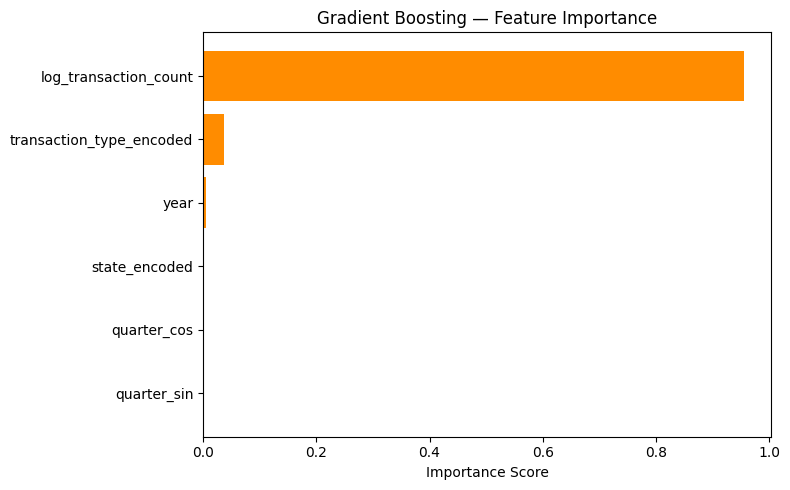

,feature,importance
5,log_transaction_count,0.955413
4,transaction_type_encoded,0.037395
0,year,0.004781
3,state_encoded,0.001706
2,quarter_cos,0.000393
1,quarter_sin,0.000312


In [58]:
# Feature importance from best Gradient Boosting model
best_gb      = rand_gb.best_estimator_
importances  = best_gb.feature_importances_
feat_df      = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df      = feat_df.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['feature'], feat_df['importance'], color='darkorange')
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
display(feat_df.sort_values('importance', ascending=False))

# **Conclusion**

This project successfully demonstrated a complete end-to-end data science pipeline for PhonePe Transaction Insights:

**ETL Pipeline:** 9 PostgreSQL tables populated from nested JSON files covering 5,034 to 20,608 rows across transaction, user, and insurance data from 2018–2024.

**5 Business Case Studies — Key Insights:**
1. **Transaction Dynamics:** Maharashtra, Karnataka, Telangana drive 60%+ of value. Merchant payments growing fastest. Q4 is peak season.
2. **Device & Engagement:** Xiaomi dominates the device base. Small urban states (Goa, Chandigarh) have the highest engagement ratios. Millions of registered but dormant users represent a massive re-engagement opportunity.
3. **Insurance:** Exponential growth since 2022 but penetration <1% in every state — the entire transaction user base is an untapped insurance market.
4. **Market Expansion:** Pareto concentration at pincode level. Districts with high count but low avg value need BNPL/credit products.
5. **User Registration:** Registration-to-activation gap is widening. Urban saturation risk — rural expansion via 'PhonePe for Bharat' is the next growth lever.

**Hypothesis Testing:** ANOVA confirmed transaction amounts differ by type. Pearson correlation confirmed strong link between registered users and transaction count. Kruskal-Wallis confirmed statistically significant quarterly seasonality.

**ML Modeling:** Gradient Boosting Regressor (after RandomizedSearchCV tuning) achieved the best R² and lowest RMSE among Linear Regression, Random Forest, and Gradient Boosting — and was saved as the final deployment-ready model.

**Strategic Priority Order:**
1. 🔑 Re-engage dormant registered users (immediate revenue)
2. 🏪 Accelerate merchant onboarding (fastest growing segment)
3. 🛡️ Scale insurance cross-sell (highest margin opportunity)
4. 🌾 Rural market expansion via PhonePe for Bharat (largest long-term opportunity)
5. 📱 Device-specific app optimization (retention and ratings improvement)